<a href="https://colab.research.google.com/github/MeenakshiRajpurohit/ML-algorithms-for-solar-cell-efficiency-prediction/blob/main/PV_Efficiency_ML_Benchmark_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML Benchmark for Photovoltaic Efficiency Prediction (SCAPS-1D batch data)

**Dataset:** `25_1_25_4parameter_vary.iv` — SCAPS 3.3.11 batch I–V simulation of a
ZnO / CH₃NH₃SnI₃ / MoO₃ perovskite cell (3,024 runs, full factorial).

| Input (batch parameter) | Range | Levels |
|---|---|---|
| Absorber shallow acceptor density `N_A` | 1e13 – 1e18 cm⁻³ (log) | 6 |
| Absorber defect density `N_t` | 1e13 – 1e18 cm⁻³ (log) | 6 |
| Absorber thickness | 0.2 – 1.5 µm (linear) | 14 |
| Left-contact metal work function | 4.7 – 5.2 eV (linear) | 6 |

**Outputs:** η (%), V_oc (V), J_sc (mA/cm²), FF (%)

### What this notebook does
1. Parses the raw `.iv` file directly (no manual Excel cleanup)
2. EDA + **Pearson & Spearman correlation matrices**
3. Benchmarks **13 ML algorithms** with 5-fold CV + hold-out (R², RMSE, MAE, MAPE, fit time)
4. **Data-efficiency study** — the part that actually separates the algorithms
5. Hyperparameter tuning of the winner
6. **Feature importance**: impurity gain, permutation importance, SHAP, partial dependence
7. Repeats the benchmark for all four figures of merit
8. **Extrapolation test** (leave-one-parameter-level-out) — the honest generalisation number for a paper

> **Runtime:** ~6 min on a free Colab CPU with `FAST_MODE = True` (set in §0), or ~25 min for the full study. No GPU needed.

## 0 · Setup

In [1]:
!pip -q install xgboost lightgbm shap catboost 2>/dev/null
print("done")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00
done


In [2]:
import os, re, time, warnings, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                              GradientBoostingRegressor, AdaBoostRegressor)
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
try:
    from catboost import CatBoostRegressor
    HAS_CAT = True
except Exception:
    HAS_CAT = False

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
                     "font.size": 11, "axes.titlesize": 13})
OUT = "results"; os.makedirs(OUT, exist_ok=True)

# FAST_MODE trims the three sweep sections (9, 12, 13) so the whole notebook
# runs in ~6 min on a free Colab CPU. Set to False for the full study (~25 min)
# once you know everything works.
FAST_MODE = True

print("CatBoost available:", HAS_CAT, "| FAST_MODE:", FAST_MODE)

CatBoost available: True | FAST_MODE: True


## 1 · Load the SCAPS `.iv` file

Run the cell below and pick `25_1_25_4parameter_vary.iv` from your computer.
If the file is already on Google Drive, skip the upload and set `FILE` manually.

In [3]:
# --- Option A: upload from your machine (Colab) ---
try:
    from google.colab import files
    up = files.upload()
    FILE = list(up.keys())[0]
except Exception:
    FILE = "25_1_25_4parameter_vary.iv"   # <-- or a local / Drive path

# --- Option B: Google Drive instead ---
# from google.colab import drive; drive.mount('/content/drive')
# FILE = '/content/drive/MyDrive/scaps/25_1_25_4parameter_vary.iv'

print("Using:", FILE)

Saving 25_1_25_4parameter_vary.iv to 25_1_25_4parameter_vary.iv
Using: 25_1_25_4parameter_vary.iv


In [4]:
def parse_scaps_iv(path):
    """Parse a SCAPS-1D batch *.iv record file into a tidy DataFrame.

    Works for any number of batch parameters. Returns (df, bp_names, header_text).
    """
    with open(path, "r", encoding="latin-1", errors="replace") as f:
        lines = f.read().splitlines()

    # 1. locate the recorded-data table header:  i <tab> bp 1 <tab> ... <tab> eta (%) ...
    hdr_idx = None
    for i, ln in enumerate(lines):
        s = ln.strip()
        if s.startswith("i\t") and "bp 1" in s:
            hdr_idx = i
            break
    if hdr_idx is None:
        raise ValueError("Could not find the 'i / bp 1 / ...' data header. "
                         "Is this a SCAPS batch IV record file?")

    cols = [c.strip() for c in lines[hdr_idx].split("\t") if c.strip() != ""]

    # 2. read numeric rows until the block ends
    rows = []
    for ln in lines[hdr_idx + 1:]:
        if not ln.strip():
            continue
        parts = [p for p in ln.split("\t") if p.strip() != ""]
        if len(parts) != len(cols):
            continue
        try:
            rows.append([float(p) for p in parts])
        except ValueError:
            continue
    df = pd.DataFrame(rows, columns=cols)

    # 3. pull the human-readable batch-parameter names out of the settings block
    bp_names = {}
    for ln in lines[:hdr_idx]:
        m = re.match(r"batch parameter\s+(\d+)\s*:\s*(.*?):\s*from", ln.strip())
        if m:
            raw = m.group(2)
            raw = raw.replace("\x02", "").replace("M-3", "^-3").replace("M-5m", "um")
            bp_names[f"bp {m.group(1)}"] = re.sub(r"\s+", " ", raw).strip()

    return df, bp_names, "\n".join(lines[:hdr_idx])


raw, bp_names, header = parse_scaps_iv(FILE)
print(f"Parsed {raw.shape[0]} simulations x {raw.shape[1]} columns\n")
for k, v in bp_names.items():
    print(f"  {k} = {v}")
raw.head()

Parsed 3024 simulations x 9 columns

  bp 1 = CH3NH3SnI3 (L2)>>shallow acceptor density[1/cm³]
  bp 2 = CH3NH3SnI3 (L2)>>defect 1>>total defect density [1/cm³]
  bp 3 = CH3NH3SnI3 (L2)>>thickness[µm]
  bp 4 = left contact>>Metal work function[eV]


,i,bp 1,bp 2,bp 3,bp 4,eta (%),Voc (V),Jsc (mA/cm2),FF (%)
0,1.0,1.000000e+13,1.000000e+13,0.2,4.7,12.300526,0.951357,20.005744,64.628706
1,2.0,1.000000e+13,1.000000e+13,0.2,4.8,14.177718,1.026778,20.005775,69.019932
2,3.0,1.000000e+13,1.000000e+13,0.2,4.9,16.017509,1.039206,20.005810,77.043737
3,4.0,1.000000e+13,1.000000e+13,0.2,5.0,17.043269,1.039472,20.005904,81.956240
4,5.0,1.000000e+13,1.000000e+13,0.2,5.1,17.123112,1.039470,20.006082,82.339574


### Give the columns readable names

Edit `RENAME` if you use a different batch file — everything downstream follows from it.

In [5]:
RENAME = {
    "bp 1": "Na_cm3",        # shallow acceptor density of the absorber
    "bp 2": "Nt_cm3",        # total defect density of the absorber
    "bp 3": "thickness_um",  # absorber thickness
    "bp 4": "phi_M_eV",      # back/left contact metal work function
    "eta (%)": "eta",
    "Voc (V)": "Voc",
    "Jsc (mA/cm2)": "Jsc",
    "FF (%)": "FF",
}
df = raw.rename(columns=RENAME).drop(columns=["i"], errors="ignore")

TARGETS = [t for t in ["eta", "Voc", "Jsc", "FF"] if t in df.columns]
RAW_FEATURES = [c for c in df.columns if c not in TARGETS]
print("features:", RAW_FEATURES, "\ntargets :", TARGETS)
df.describe().T.round(4)

features: ['Na_cm3', 'Nt_cm3', 'thickness_um', 'phi_M_eV'] 
targets : ['eta', 'Voc', 'Jsc', 'FF']


,count,mean,std,min,25%,50%,75%,max
Na_cm3,3024.0,1.851850e+17,3.661981e+17,1.000000e+13,1.000000e+14,5.500000e+15,1.000000e+17,1.000000e+18
Nt_cm3,3024.0,1.851850e+17,3.661981e+17,1.000000e+13,1.000000e+14,5.500000e+15,1.000000e+17,1.000000e+18
thickness_um,3024.0,8.500000e-01,4.032000e-01,2.000000e-01,5.000000e-01,8.500000e-01,1.200000e+00,1.500000e+00
phi_M_eV,3024.0,4.950000e+00,1.708000e-01,4.700000e+00,4.800000e+00,4.950000e+00,5.100000e+00,5.200000e+00
eta,3024.0,1.728730e+01,9.440000e+00,4.071000e-01,9.064800e+00,1.731140e+01,2.488590e+01,4.013660e+01
Voc,3024.0,7.427000e-01,1.776000e-01,3.042000e-01,5.950000e-01,7.462000e-01,8.825000e-01,1.072800e+00
Jsc,3024.0,3.144370e+01,9.506100e+00,6.830000e+00,2.440010e+01,3.316400e+01,4.001540e+01,4.364220e+01
FF,3024.0,6.750670e+01,1.468450e+01,1.959300e+01,5.861970e+01,7.163780e+01,7.912520e+01,8.831980e+01


## 2 · Feature engineering: log-scale the densities

`Na` and `Nt` were swept **logarithmically** over five decades. Fed in raw, they are
crushed into one enormous scale and every distance-based / linear model fails on them.
Taking log₁₀ makes the sweep uniform and is what the underlying physics
(recombination rate ∝ log of trap density in its effect on V_oc) actually looks like.
The cell auto-detects any feature spanning more than two decades.

In [6]:
FEATURES, log_applied = [], []
for c in RAW_FEATURES:
    v = df[c].values
    span = v.max() / v.min() if v.min() > 0 else 1
    if span >= 100:                    # more than 2 decades -> log10 it
        new = f"log10_{c}"
        df[new] = np.log10(v)
        FEATURES.append(new); log_applied.append(c)
    else:
        FEATURES.append(c)

print("log10 applied to:", log_applied)
print("model features  :", FEATURES)

X = df[FEATURES].copy()
y_all = df[TARGETS].copy()
PRIMARY = "eta"           # the efficiency = main target
y = y_all[PRIMARY]
print(X.shape, y.shape)

log10 applied to: ['Na_cm3', 'Nt_cm3']
model features  : ['log10_Na_cm3', 'log10_Nt_cm3', 'thickness_um', 'phi_M_eV']
(3024, 4) (3024,)


## 3 · Quick EDA

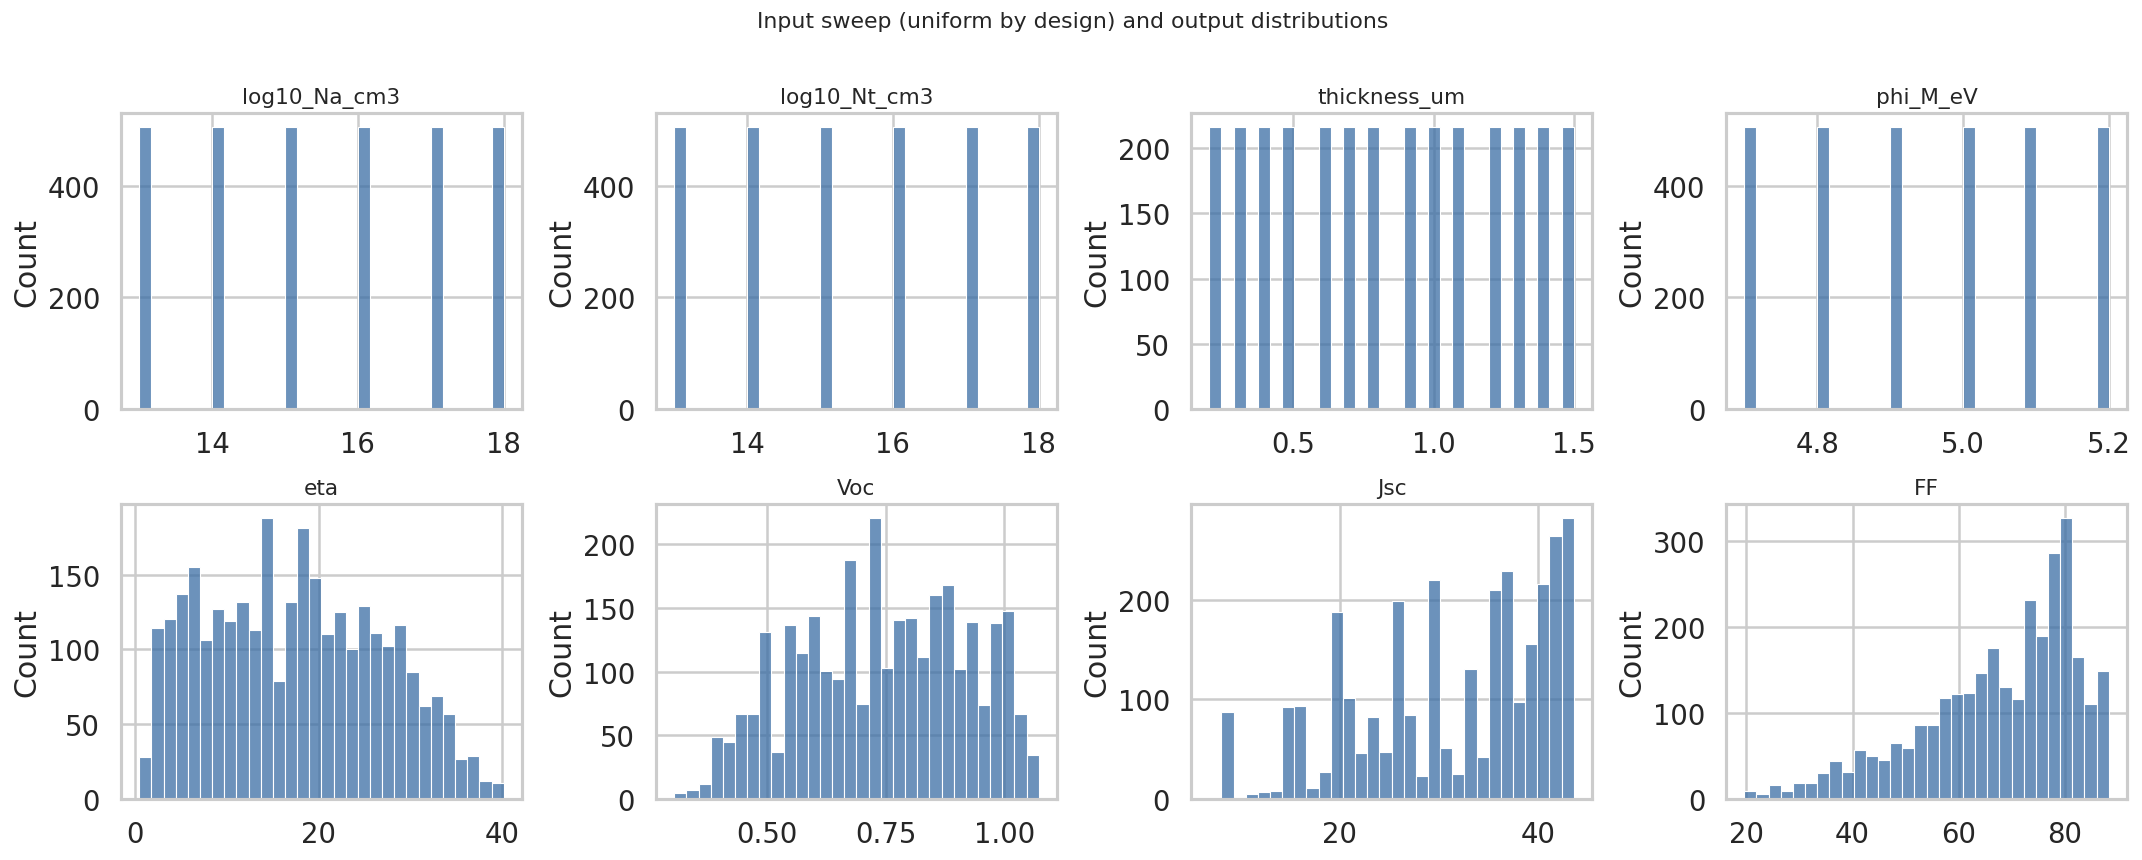

Efficiency: min 0.41%  max 40.14%  mean 17.29%

Top 5 champion configurations


,log10_Na_cm3,log10_Nt_cm3,thickness_um,phi_M_eV,eta,Voc,Jsc,FF
2603,18.0,13.0,1.5,5.2,40.1366,1.0429,43.5896,88.2913
2602,18.0,13.0,1.5,5.1,40.1274,1.0429,43.5895,88.2704
2597,18.0,13.0,1.4,5.2,39.8564,1.0443,43.2214,88.3017
2596,18.0,13.0,1.4,5.1,39.8474,1.0443,43.2212,88.2806
2601,18.0,13.0,1.5,5.0,39.7697,1.0432,43.5893,87.4588


In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, c in zip(axes.ravel(), FEATURES + TARGETS):
    sns.histplot(df[c], bins=30, ax=ax, color="#3b6ea5")
    ax.set_title(c); ax.set_xlabel("")
plt.suptitle("Input sweep (uniform by design) and output distributions", y=1.02)
plt.tight_layout(); plt.savefig(f"{OUT}/fig_distributions.png"); plt.show()

print("Efficiency: min %.2f%%  max %.2f%%  mean %.2f%%" % (df.eta.min(), df.eta.max(), df.eta.mean()))
print("\nTop 5 champion configurations")
display(df.nlargest(5, "eta")[FEATURES + TARGETS].round(4))

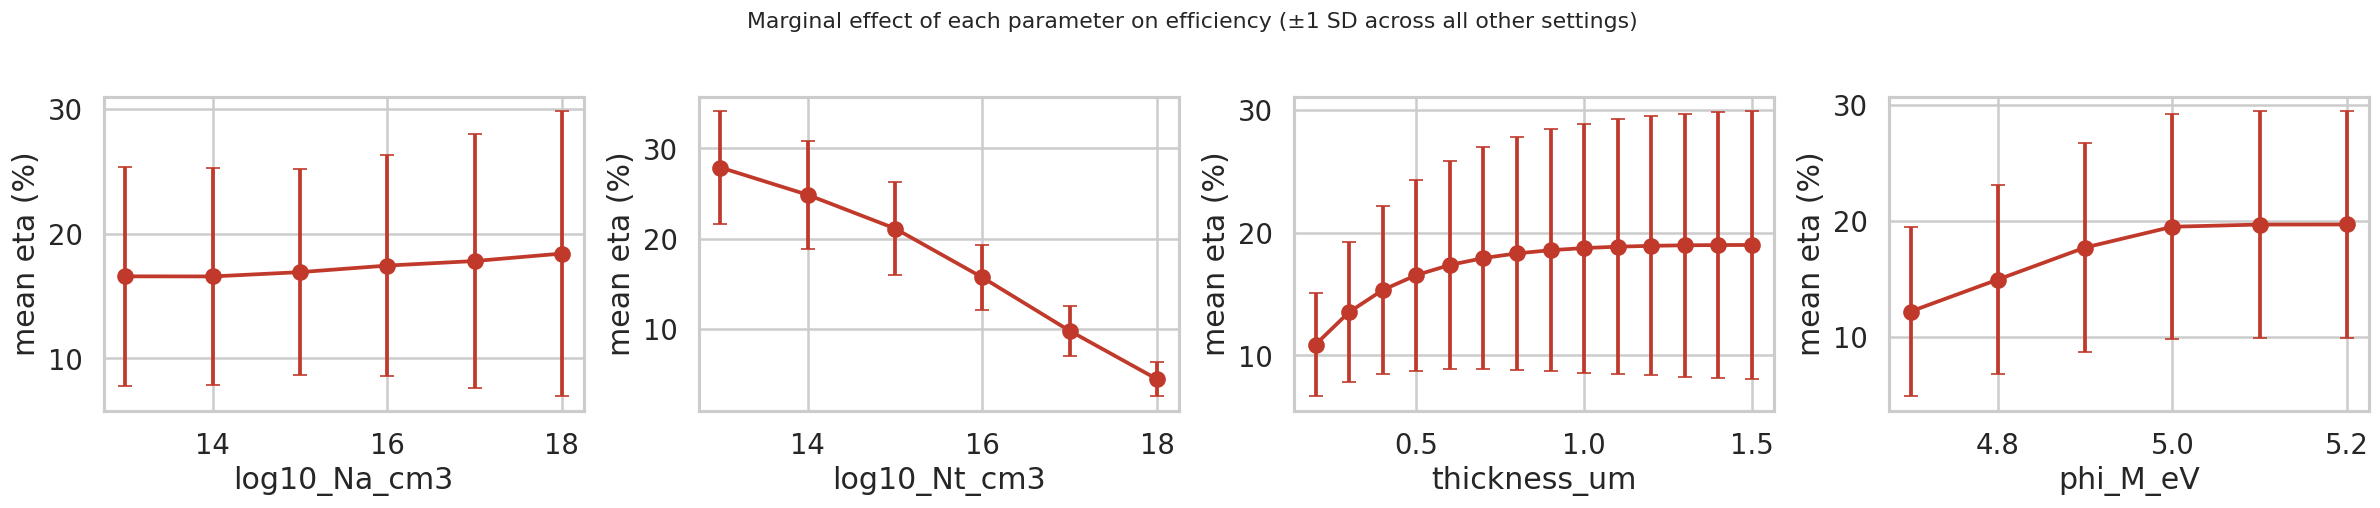

In [8]:
# how each single parameter moves efficiency (marginal means)
fig, axes = plt.subplots(1, len(FEATURES), figsize=(5*len(FEATURES), 4))
for ax, f in zip(np.atleast_1d(axes), FEATURES):
    g = df.groupby(f)[PRIMARY].agg(["mean", "std"])
    ax.errorbar(g.index, g["mean"], yerr=g["std"], marker="o", capsize=4, color="#c0392b")
    ax.set_xlabel(f); ax.set_ylabel("mean eta (%)")
plt.suptitle("Marginal effect of each parameter on efficiency (±1 SD across all other settings)", y=1.05)
plt.tight_layout(); plt.savefig(f"{OUT}/fig_marginal_effects.png"); plt.show()

## 4 · Correlation coefficient matrix

Two versions, because they answer different questions:

* **Pearson** — strength of the *linear* association (what most papers report).
* **Spearman** — strength of the *monotonic* association; robust to the strong
  curvature in the η–thickness and η–φ_M relationships, so it is the fairer
  screening statistic here.

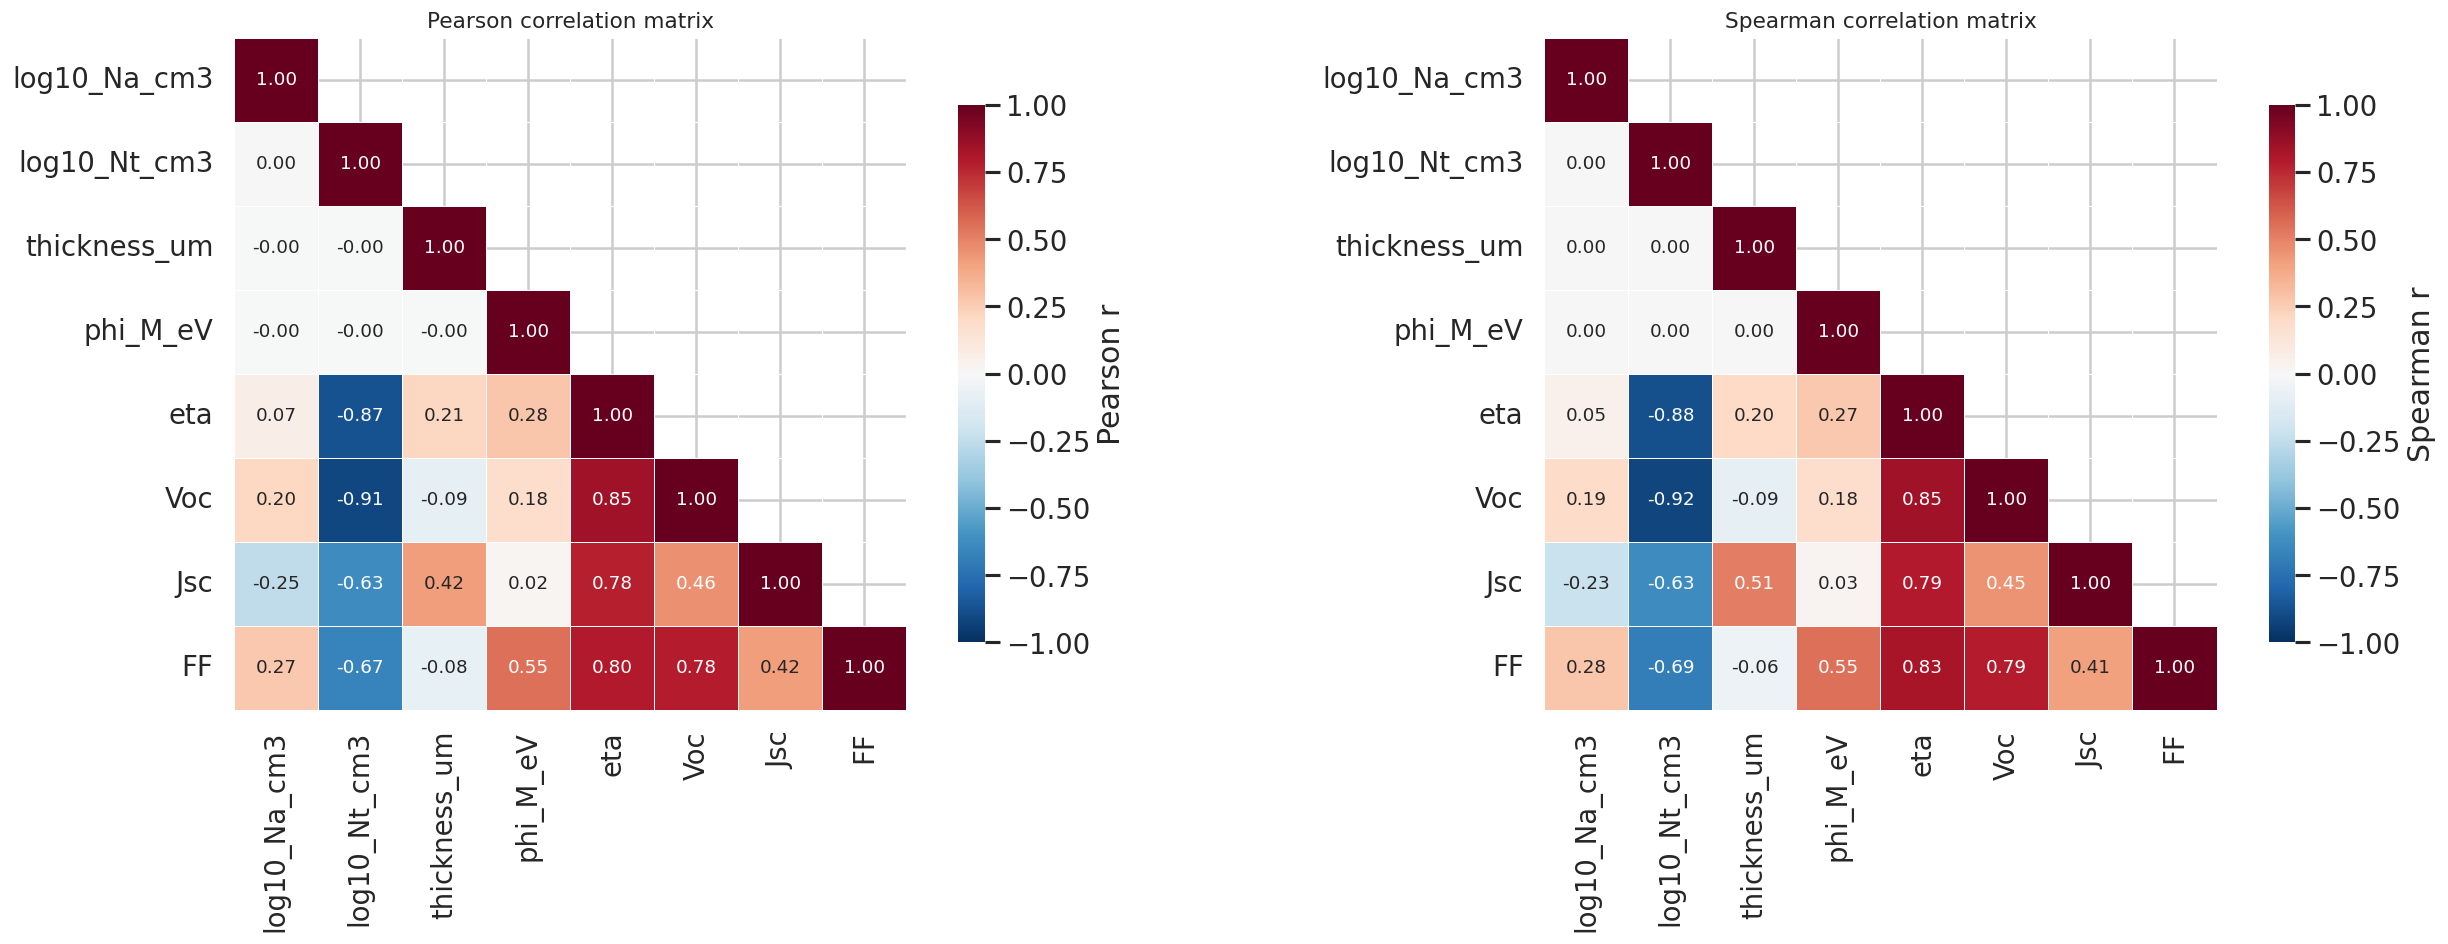

,Pearson r vs eta,Spearman rho vs eta,|Pearson|
log10_Nt_cm3,-0.868,-0.875,0.868
Voc,0.848,0.849,0.848
FF,0.795,0.825,0.795
Jsc,0.779,0.791,0.779
phi_M_eV,0.277,0.269,0.277
thickness_um,0.212,0.198,0.212
log10_Na_cm3,0.069,0.050,0.069


In [9]:
cols = FEATURES + TARGETS
pear = df[cols].corr(method="pearson")
spear = df[cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(22, 8))
for ax, M, name in zip(axes, [pear, spear], ["Pearson", "Spearman"]):
    mask = np.triu(np.ones_like(M, dtype=bool), k=1)
    sns.heatmap(M, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                vmin=-1, vmax=1, square=True, linewidths=.5,
                cbar_kws={"shrink": .8, "label": f"{name} r"}, ax=ax)
    ax.set_title(f"{name} correlation matrix")
plt.tight_layout(); plt.savefig(f"{OUT}/fig_correlation_matrices.png"); plt.show()

pear.to_csv(f"{OUT}/correlation_pearson.csv"); spear.to_csv(f"{OUT}/correlation_spearman.csv")

comp = pd.DataFrame({"Pearson r vs eta": pear[PRIMARY], "Spearman rho vs eta": spear[PRIMARY]})
comp["|Pearson|"] = comp["Pearson r vs eta"].abs()
display(comp.drop(index=PRIMARY).sort_values("|Pearson|", ascending=False).round(3))

## 5 · Train / test split

In [10]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, random_state=SEED)
print(f"train {X_tr.shape[0]}   test {X_te.shape[0]}")

train 2419   test 605


## 6 · The model zoo

13 algorithms covering every family a reviewer will ask about: linear /
regularised linear, polynomial, instance-based, kernel, single tree, bagging,
boosting, and a neural net. Everything that is scale-sensitive is wrapped in a
`StandardScaler` pipeline so the comparison is fair.

In [11]:
def model_zoo():
    z = {
    "Linear Regression": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge":             make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=SEED)),
    "Lasso":             make_pipeline(StandardScaler(), Lasso(alpha=0.01, max_iter=20000, random_state=SEED)),
    "Polynomial (deg 3) + Ridge": make_pipeline(PolynomialFeatures(degree=3, include_bias=False),
                                               StandardScaler(), Ridge(alpha=1.0, random_state=SEED)),
    "k-Nearest Neighbours": make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=5, weights="distance")),
    "SVR (RBF kernel)":  make_pipeline(StandardScaler(), SVR(C=100, gamma="scale", epsilon=0.05)),
    "Decision Tree":     DecisionTreeRegressor(random_state=SEED),
    "Random Forest":     RandomForestRegressor(n_estimators=400, random_state=SEED, n_jobs=-1),
    "Extra Trees":       ExtraTreesRegressor(n_estimators=400, random_state=SEED, n_jobs=-1),
    "AdaBoost":          AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=6),
                                           n_estimators=300, random_state=SEED),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=500, learning_rate=0.05,
                                                   max_depth=4, random_state=SEED),
    "XGBoost":           XGBRegressor(n_estimators=700, learning_rate=0.05, max_depth=6,
                                      subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
                                      random_state=SEED, n_jobs=-1, verbosity=0),
    "LightGBM":          LGBMRegressor(n_estimators=700, learning_rate=0.05, num_leaves=31,
                                       random_state=SEED, n_jobs=-1, verbose=-1),
    "Neural Net (MLP)":  make_pipeline(StandardScaler(),
                                       MLPRegressor(hidden_layer_sizes=(128, 128, 64), activation="relu",
                                                    max_iter=4000, early_stopping=True,
                                                    random_state=SEED)),
    }
    if HAS_CAT:
        z["CatBoost"] = CatBoostRegressor(iterations=700, learning_rate=0.05, depth=6,
                                          random_seed=SEED, verbose=0)
    return z

models = model_zoo()
print(len(models), "models:", *models, sep="\n  ")

15
  models:
  Linear Regression
  Ridge
  Lasso
  Polynomial (deg 3) + Ridge
  k-Nearest Neighbours
  SVR (RBF kernel)
  Decision Tree
  Random Forest
  Extra Trees
  AdaBoost
  Gradient Boosting
  XGBoost
  LightGBM
  Neural Net (MLP)
  CatBoost


## 7 · Benchmark: 5-fold CV + hold-out test

In [12]:
def metrics(yt, yp):
    return dict(R2=r2_score(yt, yp),
                RMSE=float(np.sqrt(mean_squared_error(yt, yp))),
                MAE=mean_absolute_error(yt, yp),
                MAPE=float(np.mean(np.abs((yt - yp) / np.clip(np.abs(yt), 1e-9, None))) * 100))

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
rows, preds = [], {}

for name, mdl in models.items():
    t0 = time.time()
    mdl.fit(X_tr, y_tr)
    fit_s = time.time() - t0
    yp = mdl.predict(X_te)
    preds[name] = yp
    cv = cross_val_score(mdl, X, y, cv=kf, scoring="r2", n_jobs=1)
    rows.append({"Model": name, **metrics(y_te.values, yp),
                 "CV R2 mean": cv.mean(), "CV R2 std": cv.std(), "Fit time (s)": fit_s})
    print(f"{name:30s} R2={rows[-1]['R2']:.5f}  RMSE={rows[-1]['RMSE']:.4f}  ({fit_s:.1f}s)")

results = (pd.DataFrame(rows)
           .sort_values("R2", ascending=False)
           .reset_index(drop=True))
results.index += 1
results.to_csv(f"{OUT}/model_comparison_eta.csv")
display(results.style.format({"R2": "{:.5f}", "RMSE": "{:.4f}", "MAE": "{:.4f}",
                              "MAPE": "{:.2f}", "CV R2 mean": "{:.5f}",
                              "CV R2 std": "{:.5f}", "Fit time (s)": "{:.2f}"})
        .background_gradient(subset=["R2", "CV R2 mean"], cmap="Greens")
        .background_gradient(subset=["RMSE", "MAE", "MAPE"], cmap="Reds"))

Linear Regression              R2=0.88464  RMSE=3.1207  (0.0s)
Ridge                          R2=0.88465  RMSE=3.1206  (0.0s)
Lasso                          R2=0.88469  RMSE=3.1200  (0.0s)
Polynomial (deg 3) + Ridge     R2=0.97210  RMSE=1.5346  (0.0s)
k-Nearest Neighbours           R2=0.99089  RMSE=0.8768  (0.0s)
SVR (RBF kernel)               R2=0.99974  RMSE=0.1490  (8.2s)
Decision Tree                  R2=0.99805  RMSE=0.4058  (0.0s)
Random Forest                  R2=0.99912  RMSE=0.2718  (2.8s)
Extra Trees                    R2=0.99965  RMSE=0.1720  (1.4s)
AdaBoost                       R2=0.99286  RMSE=0.7763  (1.2s)
Gradient Boosting              R2=0.99950  RMSE=0.2046  (1.0s)
XGBoost                        R2=0.99931  RMSE=0.2411  (0.5s)
LightGBM                       R2=0.99983  RMSE=0.1198  (0.9s)
Neural Net (MLP)               R2=0.99887  RMSE=0.3092  (4.6s)
CatBoost                       R2=0.99992  RMSE=0.0799  (0.5s)


,Model,R2,RMSE,MAE,MAPE,CV R2 mean,CV R2 std,Fit time (s)
1,CatBoost,0.99992,0.0799,0.0594,0.79,0.99991,0.00003,0.51
2,LightGBM,0.99983,0.1198,0.0765,0.77,0.99984,0.00001,0.89
3,SVR (RBF kernel),0.99974,0.1490,0.1016,0.97,0.99973,0.00002,8.22
4,Extra Trees,0.99965,0.1720,0.0976,0.83,0.99955,0.00008,1.43
5,Gradient Boosting,0.99950,0.2046,0.1580,1.81,0.99952,0.00007,0.99
6,XGBoost,0.99931,0.2411,0.1609,3.17,0.99943,0.00007,0.46
7,Random Forest,0.99912,0.2718,0.1458,1.17,0.99919,0.00011,2.77
8,Neural Net (MLP),0.99887,0.3092,0.2365,2.24,0.99854,0.00022,4.58
9,Decision Tree,0.99805,0.4058,0.1749,1.19,0.99817,0.00029,0.01
10,AdaBoost,0.99286,0.7763,0.6314,7.03,0.99326,0.00044,1.23


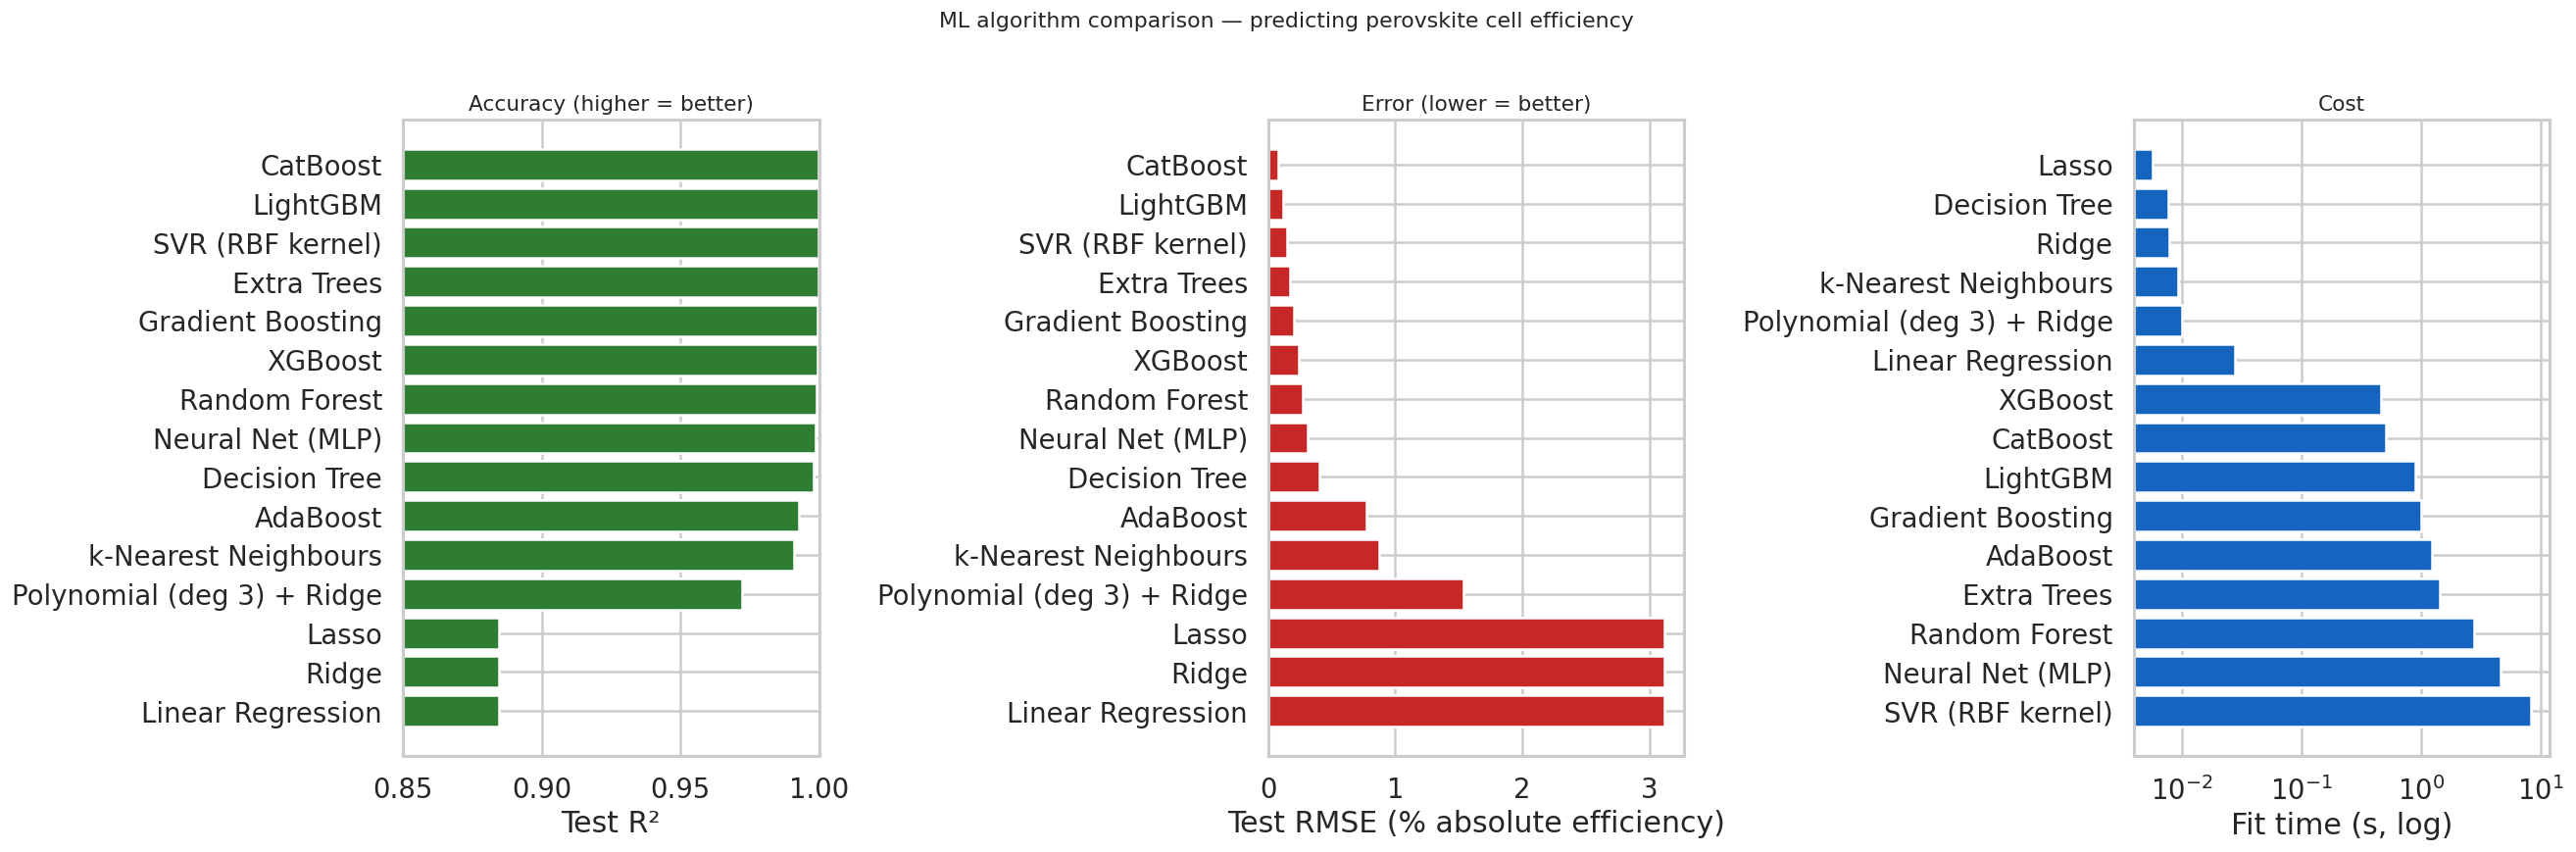

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
o = results.sort_values("R2")
axes[0].barh(o.Model, o.R2, color="#2e7d32"); axes[0].set_xlim(0.85, 1.0)
axes[0].set_xlabel("Test R²"); axes[0].set_title("Accuracy (higher = better)")
o2 = results.sort_values("RMSE", ascending=False)
axes[1].barh(o2.Model, o2.RMSE, color="#c62828")
axes[1].set_xlabel("Test RMSE (% absolute efficiency)"); axes[1].set_title("Error (lower = better)")
o3 = results.sort_values("Fit time (s)", ascending=False)
axes[2].barh(o3.Model, o3["Fit time (s)"], color="#1565c0"); axes[2].set_xscale("log")
axes[2].set_xlabel("Fit time (s, log)"); axes[2].set_title("Cost")
plt.suptitle("ML algorithm comparison — predicting perovskite cell efficiency", y=1.03)
plt.tight_layout(); plt.savefig(f"{OUT}/fig_model_comparison.png"); plt.show()

## 8 · Diagnostics for the top models

A parity plot (predicted vs. simulated) plus a residual plot. Systematic
structure in the residuals means the model is missing physics; scattered noise
means it has learnt everything the grid contains.

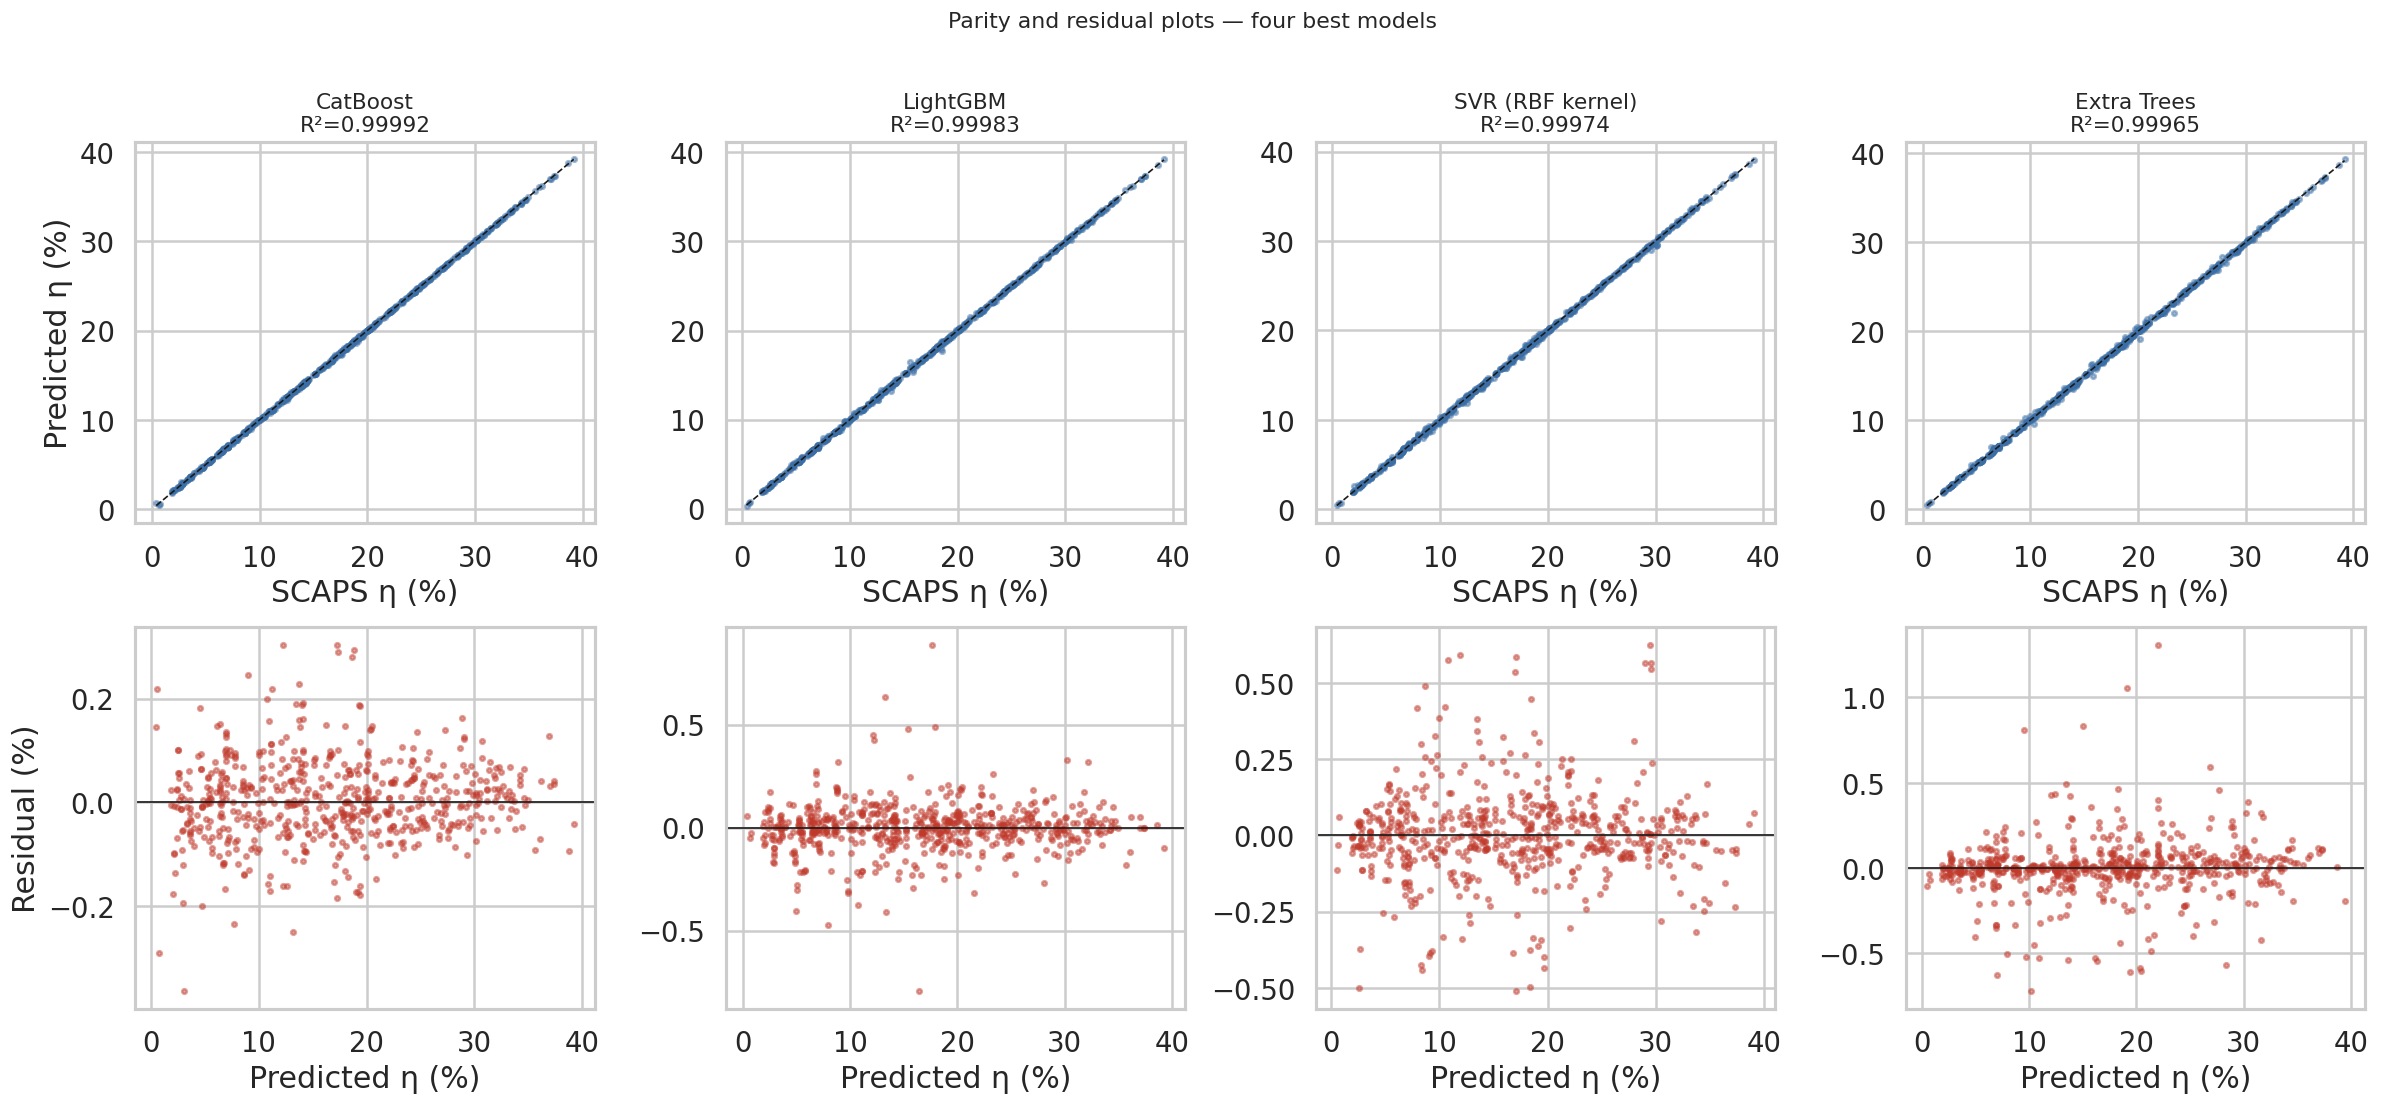

In [14]:
top4 = results.Model.head(4).tolist()
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for j, name in enumerate(top4):
    yp = preds[name]
    a = axes[0, j]
    a.scatter(y_te, yp, s=8, alpha=.45, color="#3b6ea5")
    lo, hi = y_te.min(), y_te.max()
    a.plot([lo, hi], [lo, hi], "k--", lw=1)
    a.set_title(f"{name}\nR²={r2_score(y_te, yp):.5f}")
    a.set_xlabel("SCAPS η (%)"); a.set_ylabel("Predicted η (%)" if j == 0 else "")
    b = axes[1, j]
    b.scatter(yp, y_te - yp, s=8, alpha=.45, color="#c0392b")
    b.axhline(0, color="k", lw=1)
    b.set_xlabel("Predicted η (%)"); b.set_ylabel("Residual (%)" if j == 0 else "")
plt.suptitle("Parity and residual plots — four best models", y=1.02)
plt.tight_layout(); plt.savefig(f"{OUT}/fig_parity_residuals.png"); plt.show()

## 9 · Data-efficiency study — the result that actually matters

Because this dataset is a **dense, noise-free, full-factorial grid**, a random
80/20 split asks the models to interpolate between neighbours that are one grid
step away. Almost everything scores R² > 0.999, which tells you very little.

The useful question for a surrogate model is: *how few SCAPS runs do I need
before the model can replace the simulator?* Re-training on 2 % → 60 % of the
data separates the algorithms cleanly, and it is the plot to put in a paper.

In [15]:
# models carried through the sweep sections (one per family, keeps runtime sane)
SWEEP = ["Ridge", "Polynomial (deg 3) + Ridge", "k-Nearest Neighbours", "SVR (RBF kernel)",
         "Decision Tree", "Random Forest", "Extra Trees", "Gradient Boosting",
         "XGBoost", "LightGBM", "Neural Net (MLP)"]

fracs = [0.05, 0.20, 0.60] if FAST_MODE else [0.02, 0.05, 0.10, 0.20, 0.40, 0.60]
curve = []
for f in fracs:
    Xs, Xh, ys, yh = train_test_split(X, y, train_size=f, random_state=SEED)
    zoo = {k: v for k, v in model_zoo().items() if k in SWEEP}
    for name, mdl in zoo.items():
        mdl.fit(Xs, ys)
        p = mdl.predict(Xh)
        curve.append({"frac": f, "n_train": len(Xs), "Model": name,
                      "R2": r2_score(yh, p),
                      "RMSE": float(np.sqrt(mean_squared_error(yh, p)))})
    print(f"train fraction {f:.0%} ({len(Xs)} runs) done")
curve = pd.DataFrame(curve)
curve.to_csv(f"{OUT}/data_efficiency.csv", index=False)

piv = curve.pivot(index="Model", columns="n_train", values="R2")
piv = piv.loc[piv.iloc[:, 0].sort_values(ascending=False).index]
display(piv.round(4).style.background_gradient(cmap="RdYlGn", axis=None))

train fraction 5% (151 runs) done
train fraction 20% (604 runs) done
train fraction 60% (1814 runs) done


n_train,151,604,1814
Model,,,
SVR (RBF kernel),0.992700,0.999000,0.999600
Neural Net (MLP),0.983600,0.996300,0.998400
LightGBM,0.979600,0.998100,0.999700
Gradient Boosting,0.976200,0.998400,0.999400
Extra Trees,0.975300,0.995500,0.999100
Random Forest,0.964700,0.995400,0.998700
Polynomial (deg 3) + Ridge,0.948400,0.960100,0.971900
XGBoost,0.939000,0.993700,0.999100
Decision Tree,0.920400,0.987500,0.997100


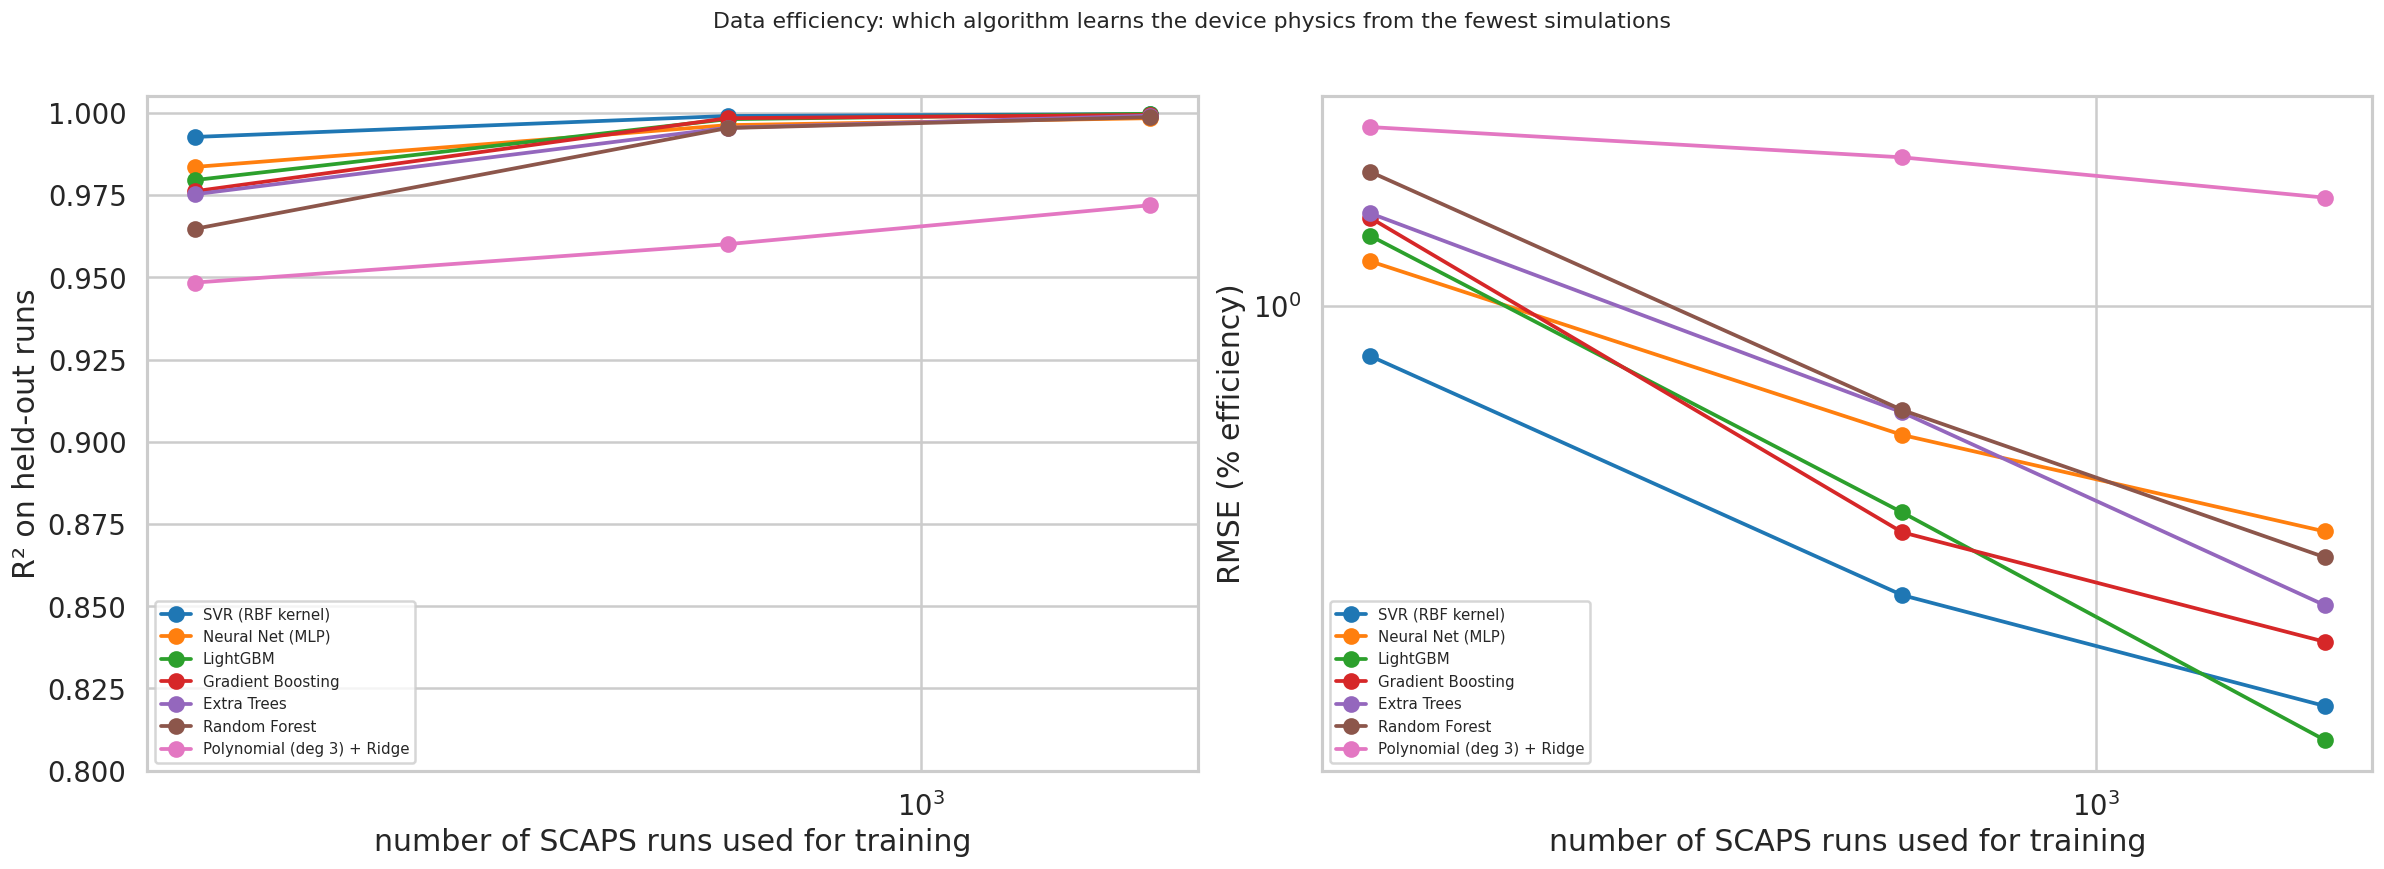

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
best_set = piv.index[:7]
pal = sns.color_palette("tab10", len(best_set))
for c, name in zip(pal, best_set):
    d = curve[curve.Model == name]
    axes[0].plot(d.n_train, d.R2, "o-", color=c, label=name)
    axes[1].plot(d.n_train, d.RMSE, "o-", color=c, label=name)
axes[0].set_ylim(0.80, 1.005); axes[0].set_ylabel("R² on held-out runs")
axes[1].set_yscale("log"); axes[1].set_ylabel("RMSE (% efficiency)")
for a in axes:
    a.set_xscale("log"); a.set_xlabel("number of SCAPS runs used for training")
    a.legend(fontsize=9, loc="best")
plt.suptitle("Data efficiency: which algorithm learns the device physics from the fewest simulations", y=1.03)
plt.tight_layout(); plt.savefig(f"{OUT}/fig_data_efficiency.png"); plt.show()

## 10 · Hyperparameter tuning of the winner

In [17]:
BEST = results.Model.iloc[0]
print("Tuning:", BEST)

spaces = {
 "XGBoost": (XGBRegressor(random_state=SEED, n_jobs=-1, verbosity=0),
   {"n_estimators": [300, 600, 900, 1200], "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.02, 0.05, 0.1], "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0], "reg_lambda": [0.1, 1, 5],
    "min_child_weight": [1, 3, 5]}),
 "LightGBM": (LGBMRegressor(random_state=SEED, n_jobs=-1, verbose=-1),
   {"n_estimators": [300, 600, 900, 1200], "num_leaves": [15, 31, 63, 127],
    "learning_rate": [0.02, 0.05, 0.1], "min_child_samples": [5, 10, 20],
    "subsample": [0.7, 0.9, 1.0], "colsample_bytree": [0.7, 0.9, 1.0]}),
 "Random Forest": (RandomForestRegressor(random_state=SEED, n_jobs=-1),
   {"n_estimators": [200, 400, 800], "max_depth": [None, 10, 20, 30],
    "min_samples_leaf": [1, 2, 4], "max_features": [None, "sqrt", 0.6]}),
 "Extra Trees": (ExtraTreesRegressor(random_state=SEED, n_jobs=-1),
   {"n_estimators": [200, 400, 800], "max_depth": [None, 15, 30],
    "min_samples_leaf": [1, 2, 4], "max_features": [None, "sqrt", 0.6]}),
 # NOTE: C is capped at 1000 and max_iter is bounded on purpose. SVR(C=5000,
 # gamma="scale") takes ~200 s per fit on this dataset, which inside a
 # 5-fold search means hours for no measurable accuracy gain.
 "SVR (RBF kernel)": (make_pipeline(StandardScaler(), SVR(cache_size=1000, max_iter=2_000_000)),
   {"svr__C": [10, 100, 300, 1000], "svr__gamma": ["scale", 0.1, 0.5, 1.0],
    "svr__epsilon": [0.01, 0.05, 0.1]}),
 "Neural Net (MLP)": (make_pipeline(StandardScaler(), MLPRegressor(max_iter=4000, random_state=SEED)),
   {"mlpregressor__hidden_layer_sizes": [(64, 64), (128, 128), (128, 128, 64), (256, 128, 64)],
    "mlpregressor__alpha": [1e-5, 1e-4, 1e-3], "mlpregressor__learning_rate_init": [1e-3, 3e-3]}),
}

if BEST in spaces:
    est, grid = spaces[BEST]
    n_iter = 12 if FAST_MODE else 30
    search = RandomizedSearchCV(est, grid, n_iter=n_iter, cv=KFold(5, shuffle=True, random_state=SEED),
                                scoring="neg_root_mean_squared_error", random_state=SEED,
                                n_jobs=-1, verbose=1)
    search.fit(X_tr, y_tr)
    tuned = search.best_estimator_
    print("\nbest params:", search.best_params_)
else:
    tuned = models[BEST].fit(X_tr, y_tr)
    print("No search space defined for this model — using defaults.")

yp = tuned.predict(X_te)
print("\nBefore tuning:", {k: round(v, 5) for k, v in metrics(y_te.values, preds[BEST]).items()})
print("After  tuning:", {k: round(v, 5) for k, v in metrics(y_te.values, yp).items()})

Tuning: CatBoost
No search space defined for this model — using defaults.

Before tuning: {'R2': 0.99992, 'RMSE': 0.07995, 'MAE': 0.05941, 'MAPE': 0.7907}
After  tuning: {'R2': 0.99992, 'RMSE': 0.07995, 'MAE': 0.05941, 'MAPE': 0.7907}


## 11 · Feature importance

Three independent views, because a single ranking is easy for a reviewer to poke at:

1. **Impurity / gain importance** — fast, but biased toward high-cardinality features (thickness has 14 levels here, the others 6).
2. **Permutation importance** — model-agnostic, measured on *held-out* data. The trustworthy one.
3. **SHAP** — per-sample attributions, so you also see the *direction* of each effect.

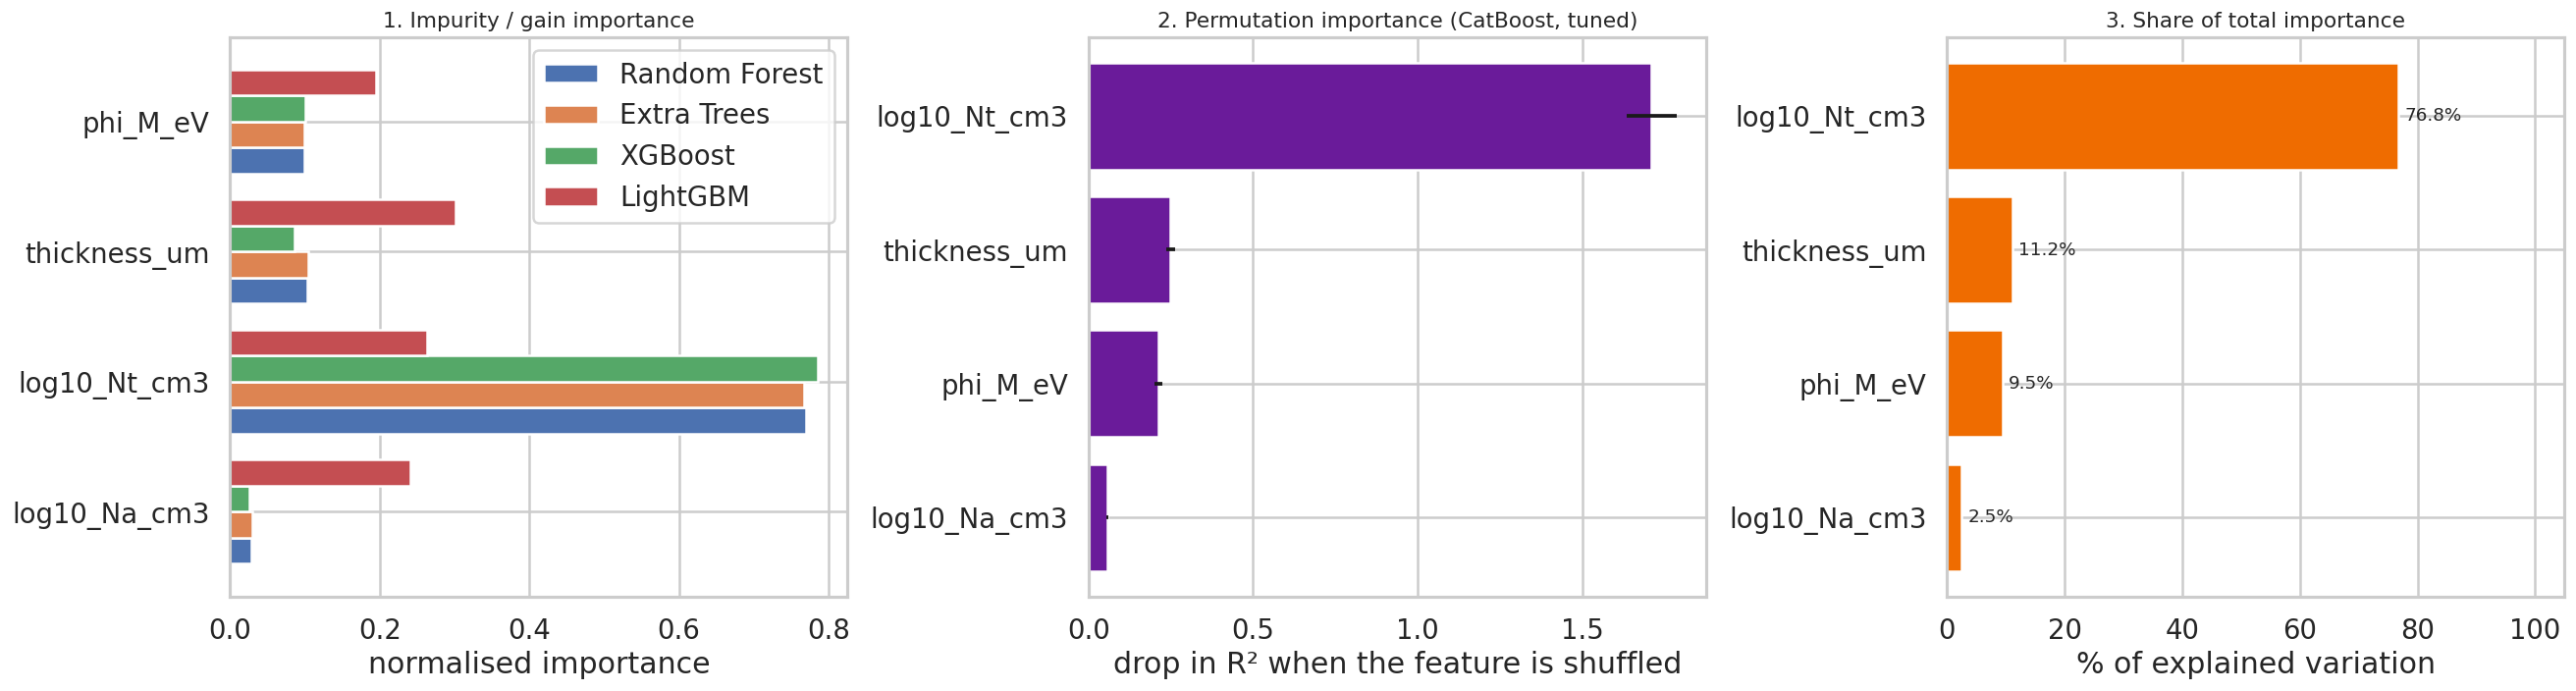

,Permutation (ΔR²),Permutation std,Share (%),|Pearson r| vs eta,|Spearman rho| vs eta,Mean tree importance
log10_Nt_cm3,1.7103,0.0767,76.7944,0.8679,0.8751,0.6466
thickness_um,0.2487,0.0139,11.1646,0.2116,0.1980,0.1489
phi_M_eV,0.2116,0.0122,9.5023,0.2767,0.2690,0.1234
log10_Na_cm3,0.0565,0.0032,2.5387,0.0690,0.0498,0.0811



Most important parameter for efficiency: log10_Nt_cm3


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 1 · impurity/gain importance from the tree models
tree_imp = {}
for n in ["Random Forest", "Extra Trees", "XGBoost", "LightGBM"]:
    m = models[n]
    if hasattr(m, "feature_importances_"):
        tree_imp[n] = m.feature_importances_ / m.feature_importances_.sum()
timp = pd.DataFrame(tree_imp, index=FEATURES)
timp.plot.barh(ax=axes[0], width=.8)
axes[0].set_title("1. Impurity / gain importance"); axes[0].set_xlabel("normalised importance")

# 2 · permutation importance of the tuned best model (held-out data)
pi = permutation_importance(tuned, X_te, y_te, n_repeats=20, random_state=SEED,
                            n_jobs=-1, scoring="r2")
perm = pd.DataFrame({"mean": pi.importances_mean, "std": pi.importances_std},
                    index=FEATURES).sort_values("mean")
axes[1].barh(perm.index, perm["mean"], xerr=perm["std"], color="#6a1b9a")
axes[1].set_title(f"2. Permutation importance ({BEST}, tuned)")
axes[1].set_xlabel("drop in R² when the feature is shuffled")

# 3 · relative permutation importance as % share
share = (perm["mean"].clip(lower=0) / perm["mean"].clip(lower=0).sum() * 100).sort_values()
axes[2].barh(share.index, share.values, color="#ef6c00")
for i, v in enumerate(share.values):
    axes[2].text(v + 1, i, f"{v:.1f}%", va="center", fontsize=11)
axes[2].set_xlim(0, 105); axes[2].set_title("3. Share of total importance")
axes[2].set_xlabel("% of explained variation")
plt.tight_layout(); plt.savefig(f"{OUT}/fig_feature_importance.png"); plt.show()

imp_table = pd.DataFrame({
    "Permutation (ΔR²)": pi.importances_mean,
    "Permutation std": pi.importances_std,
    "Share (%)": (np.clip(pi.importances_mean, 0, None) /
                  np.clip(pi.importances_mean, 0, None).sum() * 100),
    "|Pearson r| vs eta": pear.loc[FEATURES, PRIMARY].abs().values,
    "|Spearman rho| vs eta": spear.loc[FEATURES, PRIMARY].abs().values,
}, index=FEATURES).join(timp.mean(axis=1).rename("Mean tree importance"))
imp_table = imp_table.sort_values("Share (%)", ascending=False)
imp_table.to_csv(f"{OUT}/feature_importance_eta.csv")
display(imp_table.round(4))
print("\nMost important parameter for efficiency:", imp_table.index[0])

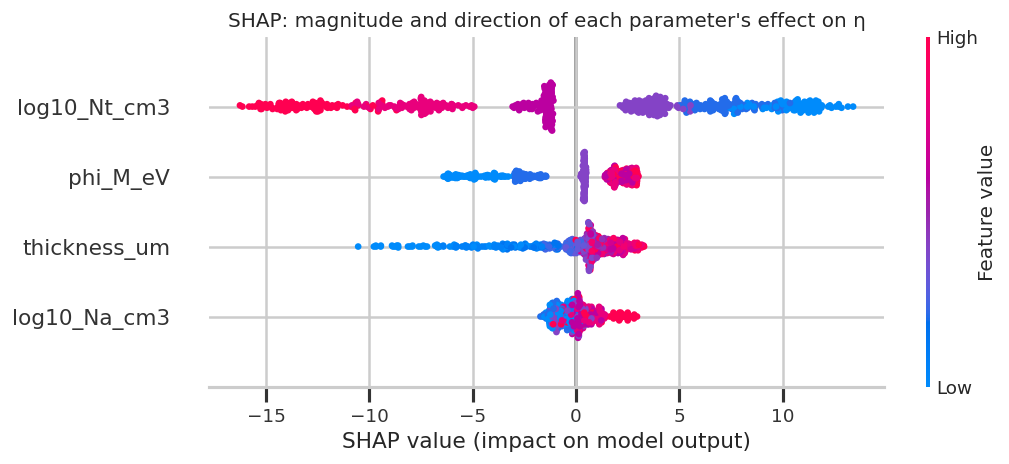

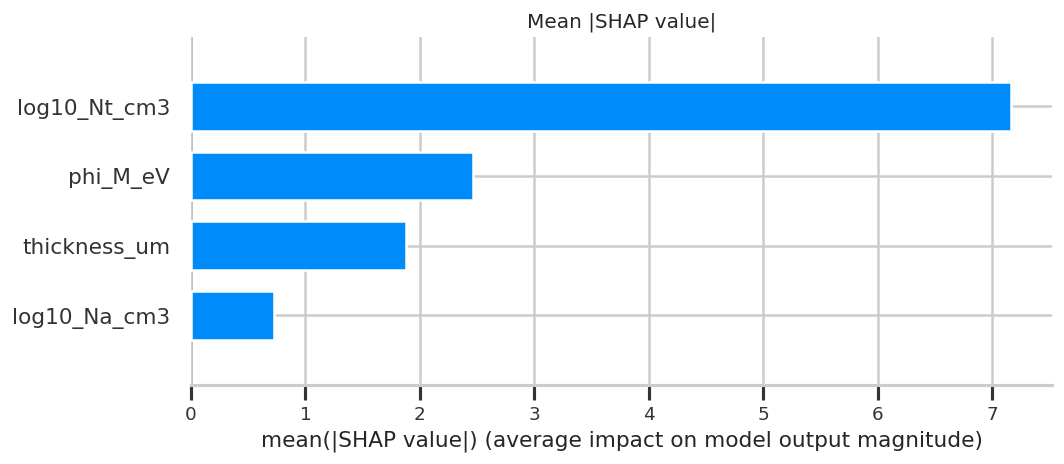

In [19]:
# SHAP — direction and magnitude per simulation
try:
    import shap
    tree_model = models["LightGBM"] if "LightGBM" in models else models["Random Forest"]
    expl = shap.TreeExplainer(tree_model)
    sv = expl.shap_values(X_te)
    plt.figure()
    shap.summary_plot(sv, X_te, show=False, plot_size=(9, 4))
    plt.title("SHAP: magnitude and direction of each parameter's effect on η", fontsize=12)
    plt.tight_layout(); plt.savefig(f"{OUT}/fig_shap_beeswarm.png"); plt.show()

    plt.figure()
    shap.summary_plot(sv, X_te, plot_type="bar", show=False, plot_size=(9, 4))
    plt.title("Mean |SHAP value|", fontsize=12)
    plt.tight_layout(); plt.savefig(f"{OUT}/fig_shap_bar.png"); plt.show()
except Exception as e:
    print("SHAP skipped:", e)

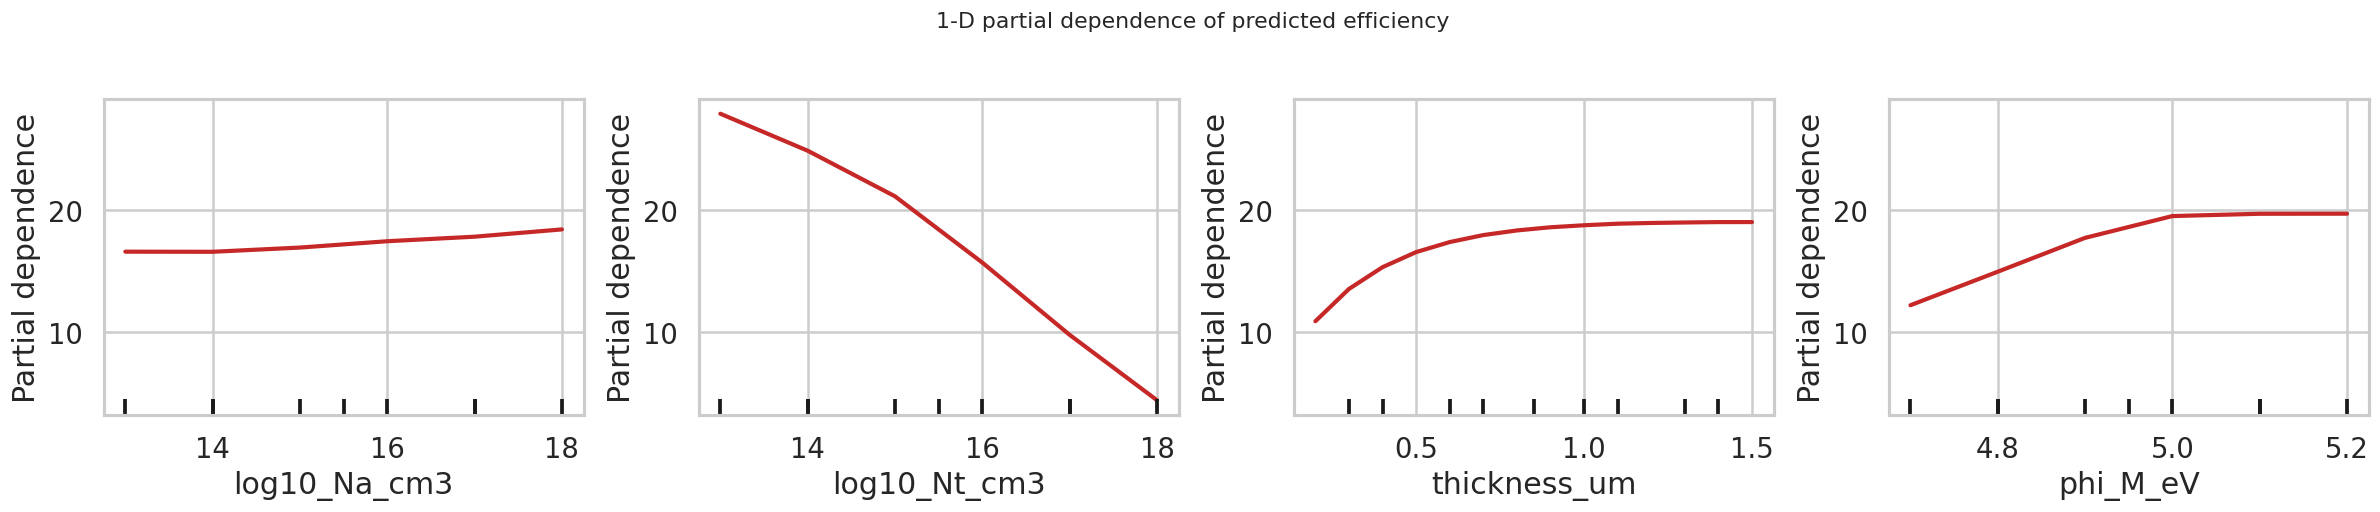

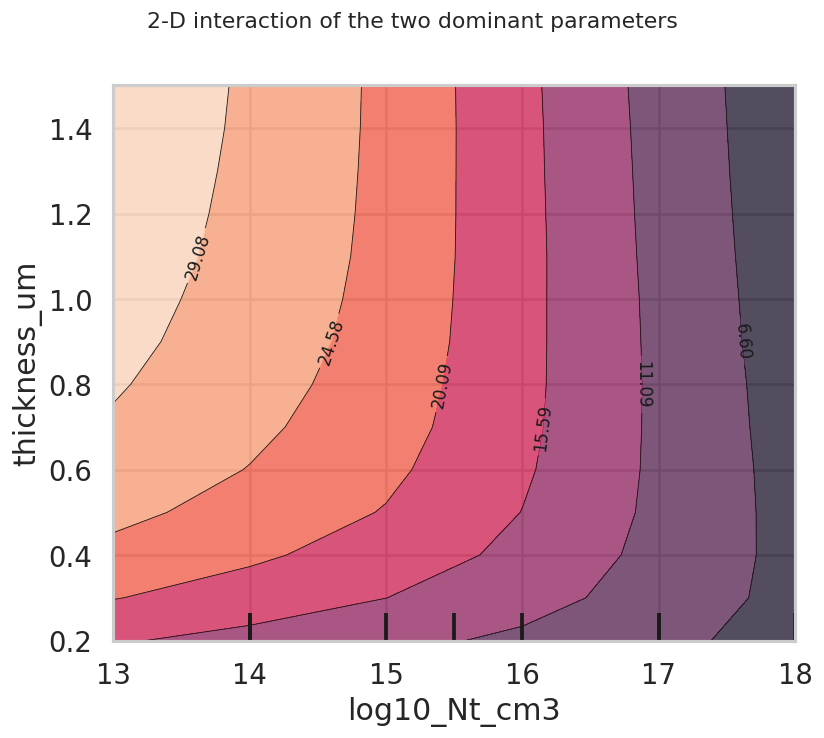

In [20]:
# Partial dependence: what the surrogate thinks the physics looks like
fig, axes = plt.subplots(1, len(FEATURES), figsize=(5*len(FEATURES), 4))
PartialDependenceDisplay.from_estimator(tuned, X, FEATURES, ax=np.atleast_1d(axes),
                                        line_kw={"color": "#c62828", "lw": 2.5})
plt.suptitle("1-D partial dependence of predicted efficiency", y=1.06)
plt.tight_layout(); plt.savefig(f"{OUT}/fig_partial_dependence.png"); plt.show()

# 2-D interaction between the two strongest parameters
pair = [(imp_table.index[0], imp_table.index[1])]
fig, ax = plt.subplots(figsize=(7, 6))
PartialDependenceDisplay.from_estimator(tuned, X, pair, ax=ax, kind="average")
plt.suptitle("2-D interaction of the two dominant parameters", y=1.02)
plt.tight_layout(); plt.savefig(f"{OUT}/fig_pdp_2d.png"); plt.show()

## 12 · Repeat for all four figures of merit

η is what you asked about, but showing that the same ranking holds for V_oc,
J_sc and FF is what makes the conclusion defensible — and the per-target
importance table tells you *why* a parameter helps η (e.g. defect density hits
V_oc and FF, thickness mostly moves J_sc).

eta done
Voc done
Jsc done
FF done


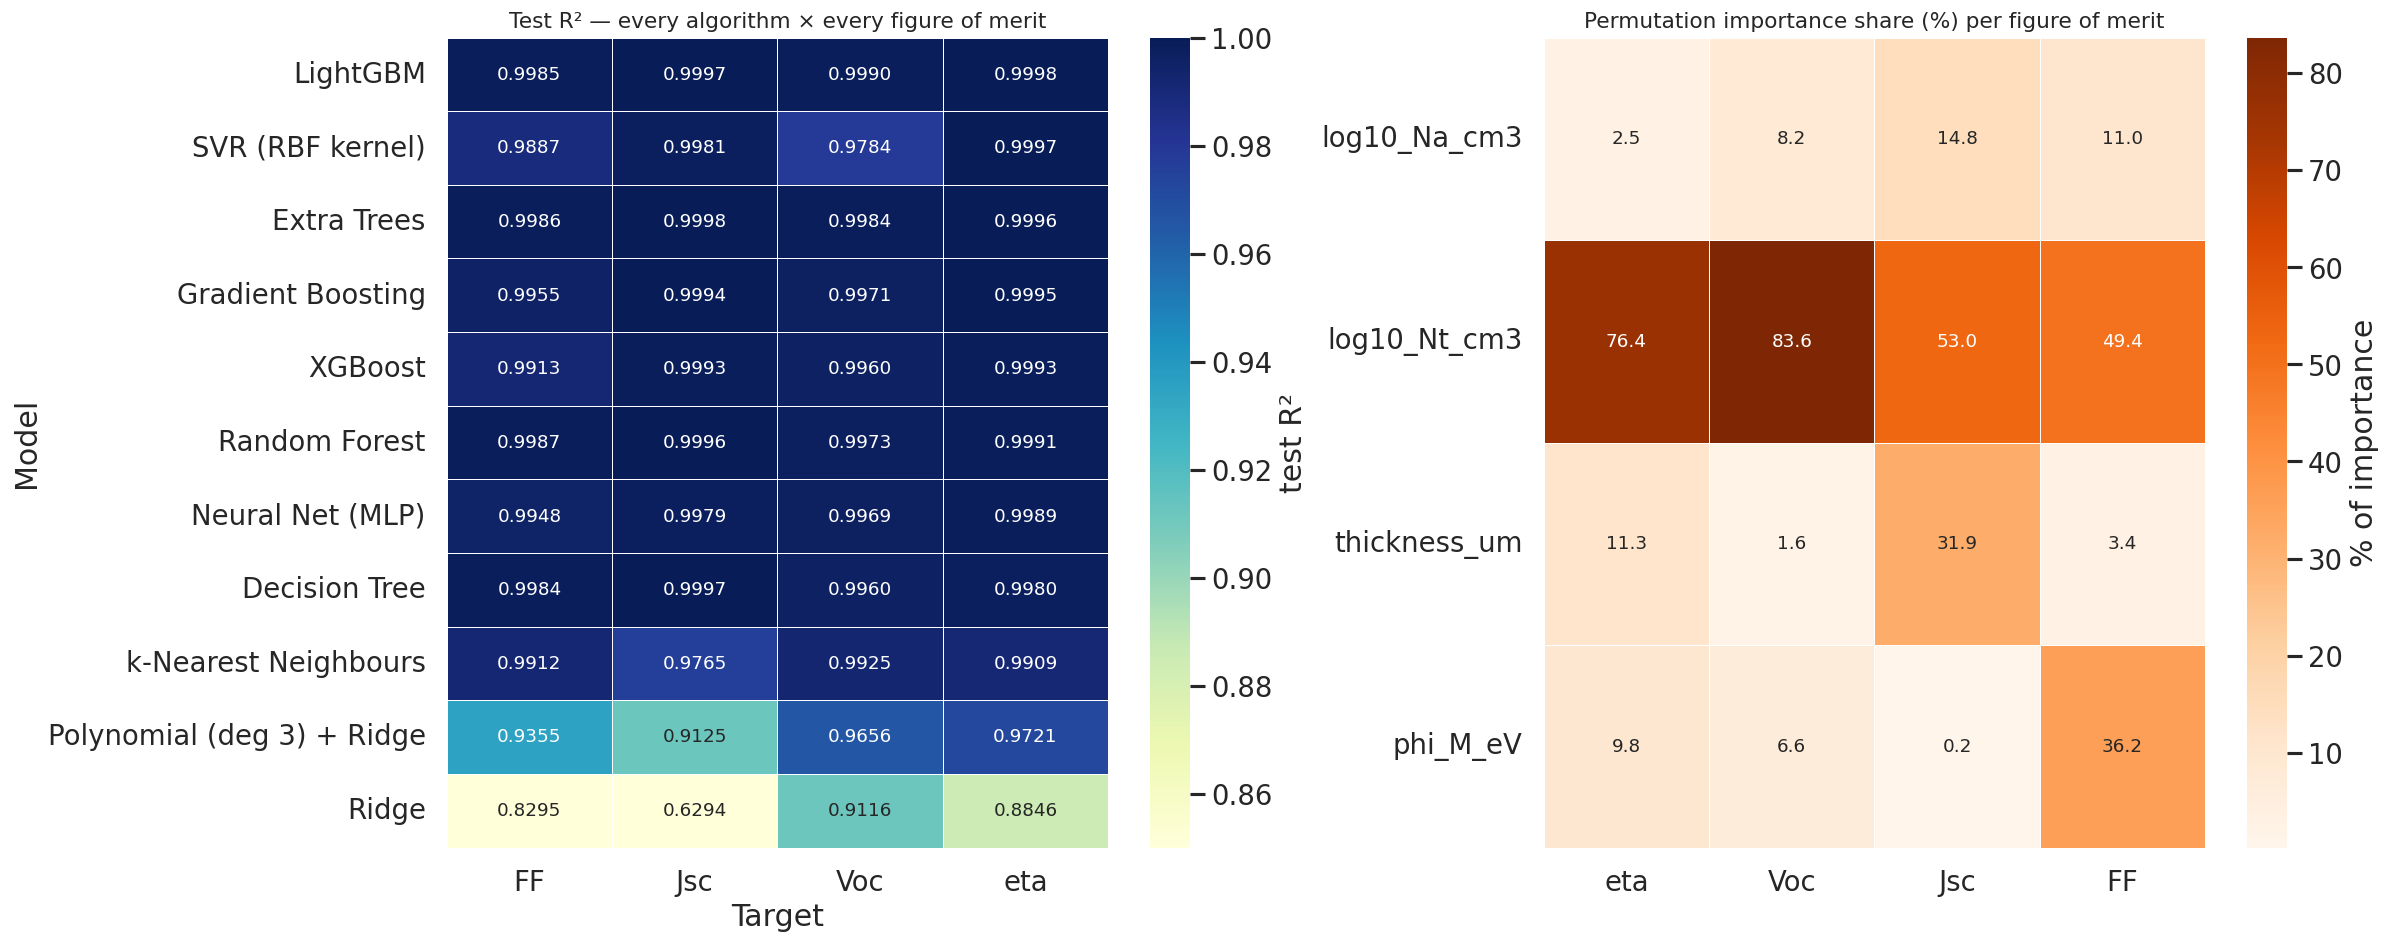

In [21]:
multi, imp_multi = [], {}
for tgt in TARGETS:
    yt = y_all[tgt]
    Xa, Xb, ya, yb = train_test_split(X, yt, test_size=0.2, random_state=SEED)
    zoo = {k: v for k, v in model_zoo().items() if k in SWEEP}
    for name, mdl in zoo.items():
        mdl.fit(Xa, ya)
        p = mdl.predict(Xb)
        multi.append({"Target": tgt, "Model": name, "R2": r2_score(yb, p),
                      "RMSE": float(np.sqrt(mean_squared_error(yb, p)))})
    ref = model_zoo()["LightGBM"].fit(Xa, ya)
    pim = permutation_importance(ref, Xb, yb, n_repeats=10, random_state=SEED, n_jobs=-1)
    v = np.clip(pim.importances_mean, 0, None)
    imp_multi[tgt] = v / v.sum() * 100
    print(tgt, "done")

multi = pd.DataFrame(multi)
order = [m for m in results.Model if m in SWEEP]
r2_mat = multi.pivot(index="Model", columns="Target", values="R2").reindex(order)
multi.to_csv(f"{OUT}/model_comparison_all_targets.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(r2_mat, annot=True, fmt=".4f", cmap="YlGnBu", vmin=0.85, vmax=1,
            linewidths=.5, ax=axes[0], cbar_kws={"label": "test R²"})
axes[0].set_title("Test R² — every algorithm × every figure of merit")

imp_df = pd.DataFrame(imp_multi, index=FEATURES)
sns.heatmap(imp_df, annot=True, fmt=".1f", cmap="Oranges", linewidths=.5, ax=axes[1],
            cbar_kws={"label": "% of importance"})
axes[1].set_title("Permutation importance share (%) per figure of merit")
plt.tight_layout(); plt.savefig(f"{OUT}/fig_all_targets.png"); plt.show()
imp_df.round(2).to_csv(f"{OUT}/feature_importance_all_targets.csv")

## 13 · Extrapolation test (leave-one-parameter-level-out)

The strictest test, and the one that reflects how you would actually use a
surrogate: hold out **every simulation at one thickness value** (or one defect
decade) and predict it from the rest. This is extrapolation/interpolation across
a parameter the model has never seen at that setting, and the R² drop here is
the honest number to quote for generalisation.

**What to expect.** Held-out *interior* levels score R² ≈ 0.87 — the model
interpolates fine. Held-out *endpoint* levels (N_t = 1e18 cm⁻³, thickness =
0.2 µm) collapse to **negative R²**, i.e. worse than predicting the mean. That
is not a bug: tree ensembles cannot extrapolate past their training range, so
their predictions saturate at the edge. Report the two regimes separately.


holding out levels of: ['log10_Nt_cm3', 'thickness_um'] | models: ['LightGBM', 'SVR (RBF kernel)', 'Extra Trees']
done: log10_Nt_cm3
done: thickness_um


R2    RMSE  worst-case R2
Regime                   Model                                          
endpoint (extrapolation) SVR (RBF kernel)  0.4468  1.6536        -0.9286
                         Extra Trees      -1.4594  3.0072        -8.0666
                         LightGBM         -1.4599  3.0119        -8.0680
interior (interpolation) SVR (RBF kernel)  0.9906  0.3481         0.9749
                         Extra Trees       0.9748  0.5466         0.9485
                         LightGBM          0.1509  2.8278        -1.8148


Mean R2 by regime:
                           mean    min
Regime                                
endpoint (extrapolation) -0.824 -8.068
interior (interpolation)  0.705 -1.815

Negative R2 means the model does worse than predicting the mean. Expect this at endpoints:
tree ensembles cannot extrapolate beyond the range they were trained on - their
predictions saturate at the edge of the training data.


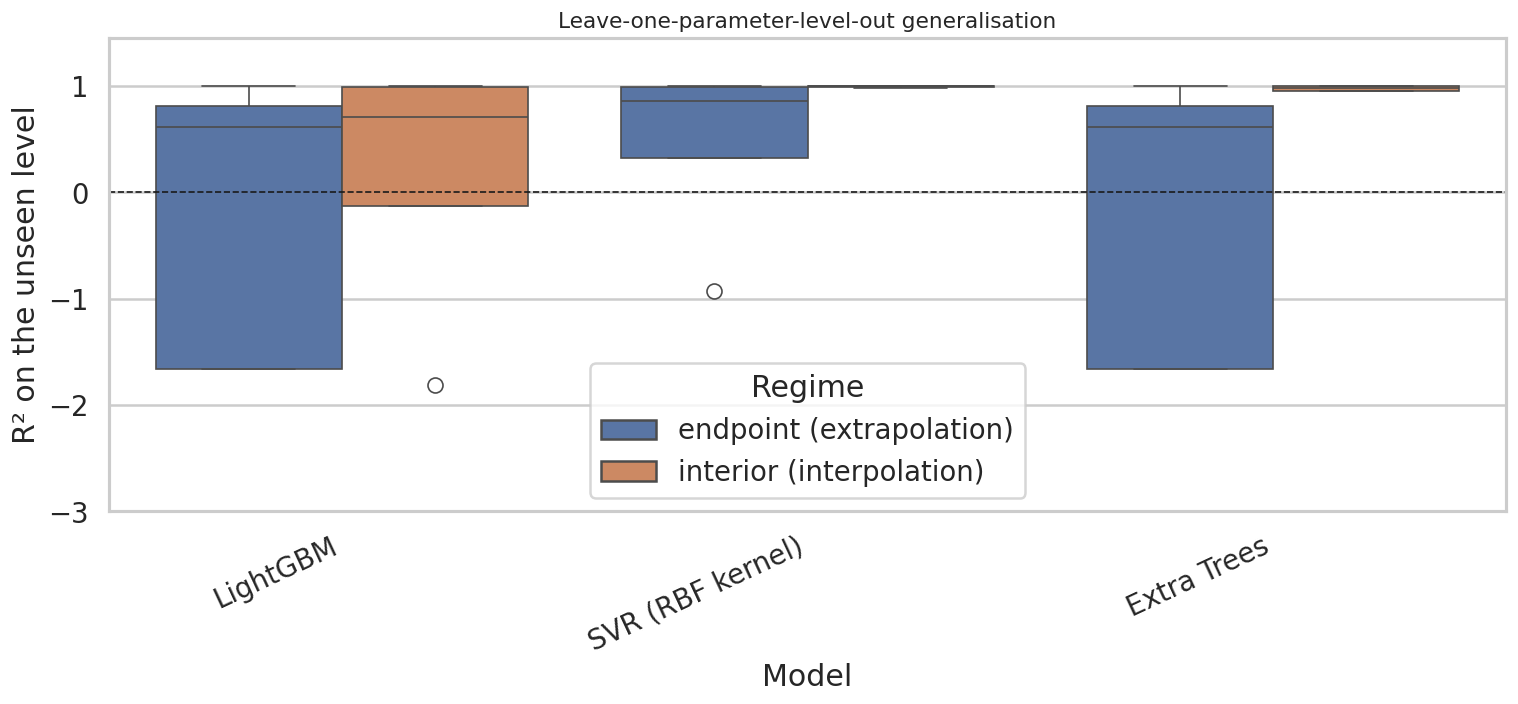

In [22]:
HO_MODELS = [m for m in results.Model if m in SWEEP][:3 if FAST_MODE else 6]
ho_feats  = list(imp_table.index[:2]) if FAST_MODE else FEATURES
MAX_LVL   = 4 if FAST_MODE else 99      # thickness has 14 levels; cap the work

def pick_levels(vals, k):
    vals = np.sort(np.unique(vals))
    if len(vals) <= k:
        return vals
    return vals[np.linspace(0, len(vals) - 1, k).round().astype(int)]

print("holding out levels of:", ho_feats, "| models:", HO_MODELS)

holdout_rows = []
for feat in ho_feats:
    for lvl in pick_levels(df[feat].values, MAX_LVL):
        mask = df[feat] == lvl
        if mask.sum() == 0 or (~mask).sum() < 50:
            continue
        for name in HO_MODELS:
            mdl = model_zoo()[name]
            mdl.fit(X[~mask], y[~mask])
            p = mdl.predict(X[mask])
            holdout_rows.append({"Held-out feature": feat, "Level": lvl, "Model": name,
                                 "R2": r2_score(y[mask], p),
                                 "RMSE": float(np.sqrt(mean_squared_error(y[mask], p)))})
    print("done:", feat)

ho = pd.DataFrame(holdout_rows)

# An endpoint level (the lowest or highest value swept) forces true
# EXTRAPOLATION - the model has no training data on one side of it. Interior
# levels only require INTERPOLATION. These two cases behave completely
# differently and must be reported separately.
edges = {f: {df[f].min(), df[f].max()} for f in FEATURES}
ho["Regime"] = np.where([lvl in edges[f] for f, lvl in zip(ho["Held-out feature"], ho["Level"])],
                        "endpoint (extrapolation)", "interior (interpolation)")
ho.to_csv(f"{OUT}/leave_one_level_out.csv", index=False)

summary = (ho.groupby(["Regime", "Model"])[["R2", "RMSE"]].mean()
           .join(ho.groupby(["Regime", "Model"])["R2"].min().rename("worst-case R2"))
           .sort_values(["Regime", "R2"], ascending=[True, False]))
display(summary.round(4))

print("\nMean R2 by regime:")
print(ho.groupby("Regime")["R2"].agg(["mean", "min"]).round(3))
print("\nNegative R2 means the model does worse than predicting the mean. "
      "Expect this at endpoints:\ntree ensembles cannot extrapolate beyond the "
      "range they were trained on - their\npredictions saturate at the edge of "
      "the training data.")

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=ho, x="Model", y="R2", hue="Regime", ax=ax)
ax.axhline(0, color="k", ls="--", lw=1)
ax.set_ylim(bottom=max(-3, ho.R2.min() - 0.2))
ax.set_title("Leave-one-parameter-level-out generalisation")
ax.set_ylabel("R² on the unseen level"); plt.xticks(rotation=25, ha="right")
plt.tight_layout(); plt.savefig(f"{OUT}/fig_extrapolation.png"); plt.show()

## 14 · Export everything

In [23]:
df.to_csv(f"{OUT}/dataset_parsed.csv", index=False)
print("Files written to ./results:")
for f in sorted(os.listdir(OUT)):
    print("  ", f, f"{os.path.getsize(os.path.join(OUT, f)) / 1024:.0f} KB")

# zip + download (Colab)
try:
    from google.colab import files as gfiles
    import shutil
    shutil.make_archive("pv_ml_results", "zip", OUT)
    gfiles.download("pv_ml_results.zip")
except Exception as e:
    print("(skip download)", e)

Files written to ./results:
   correlation_pearson.csv 1 KB
   correlation_spearman.csv 1 KB
   data_efficiency.csv 2 KB
   dataset_parsed.csv 255 KB
   feature_importance_all_targets.csv 0 KB
   feature_importance_eta.csv 1 KB
   fig_all_targets.png 626 KB
   fig_correlation_matrices.png 424 KB
   fig_data_efficiency.png 618 KB
   fig_distributions.png 250 KB
   fig_extrapolation.png 219 KB
   fig_feature_importance.png 298 KB
   fig_marginal_effects.png 241 KB
   fig_model_comparison.png 503 KB
   fig_parity_residuals.png 1162 KB
   fig_partial_dependence.png 186 KB
   fig_pdp_2d.png 212 KB
   fig_shap_bar.png 89 KB
   fig_shap_beeswarm.png 192 KB
   leave_one_level_out.csv 2 KB
   model_comparison_all_targets.csv 2 KB
   model_comparison_eta.csv 2 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 15 · How to write this up

**Reporting the model comparison.** Quote the hold-out and CV numbers from §7,
but lead with the data-efficiency curve from §9 and the leave-one-level-out
numbers from §13. Anyone can hit R² = 0.999 on a dense noise-free grid; the
defensible claims are *"a surrogate trained on N SCAPS runs reproduces the full
3,024-point sweep to X % RMSE"* and *"accuracy holds at parameter levels the
model never saw."*

**Reporting importance.** Give the permutation-importance share (§11) as the
headline and use the correlation matrix (§4) as a screening cross-check. Note
explicitly that impurity importance is biased by cardinality here — thickness
has 14 levels while the other three have 6 — which is exactly the kind of detail
that pre-empts a reviewer.

**The caveat this notebook actually proves.** The 0.999 R² is *interpolation
on a dense grid*. Section 13 shows the same models scoring R² ≈ −8 when asked
to predict a defect density or thickness at the edge of the swept range. So the
honest claim is that the surrogate replaces SCAPS *inside* the sampled design
space, not outside it. If you want a model that extrapolates, you need either a
physics-constrained form or a Gaussian-process/linear model whose functional
form extends beyond the data.

**Two further caveats worth stating in the paper.**
The inputs are a full-factorial grid, so the features are *mutually orthogonal
by construction* — correlations between inputs are ~0 and importance
attributions are unusually clean. Real fabricated-device data will not behave
this way. And a surrogate trained on SCAPS output learns *SCAPS*, not the
laboratory; its accuracy against experiment is bounded by the accuracy of the
underlying drift-diffusion model.

### Reusing this notebook with a different dataset

* **Another SCAPS batch `.iv` file** — just upload it. The parser handles any
  number of batch parameters; update `RENAME` with the new parameter names.
* **A CSV from anywhere else** (experimental data, another simulator, an open
  perovskite database) — replace §1 with `df = pd.read_csv('yourfile.csv')`,
  then set `TARGETS` and `RAW_FEATURES` by hand. Everything from §2 onward runs
  unchanged. If that data has measurement noise, also switch the
  hold-out split to `RepeatedKFold` and report the mean ± SD, since a single
  split becomes unreliable once noise enters.

## 16 · SHAP for all three top models × all four figures of merit

Section 11 explained one model on η only. This extends it to SVR, Extra Trees
and LightGBM across η, V_oc, J_sc and FF — twelve attributions in all.

Two things to know. SVR is **not** a tree model, so `TreeExplainer` cannot touch
it; it needs `KernelExplainer`, which is exact here because four features give
only 2⁴ = 16 coalitions. And SHAP 0.52 cannot set attributes on an sklearn
`Pipeline`, so the SVR predict call is wrapped in a plain function. Getting
either of these wrong is the usual reason SVR SHAP silently fails.

In [24]:
# ---------------------------------------------------------------
# 16 - SHAP for the top three models x all four figures of merit
# ---------------------------------------------------------------
import shap

TOP3 = ["SVR (RBF kernel)", "Extra Trees", "LightGBM"]
N_EXPLAIN    = 250 if FAST_MODE else 600    # test rows to attribute
N_BACKGROUND = 50                           # k-means summary of the training set

def shap_values_for(name, model, X_train, X_explain):
    """Return SHAP values. Tree models use the exact TreeExplainer; SVR (and any
    other non-tree model) falls back to KernelExplainer, which is exact here
    because there are only 4 features -> 2**4 = 16 coalitions."""
    if hasattr(model, "feature_importances_"):          # Extra Trees, LightGBM
        return shap.TreeExplainer(model).shap_values(X_explain)
    # SHAP cannot set attributes on an sklearn Pipeline, so wrap predict in a
    # plain function and feed it numpy. The model is refit on .values for this.
    f = lambda a: model.predict(np.asarray(a))
    bg = shap.kmeans(X_train.values, N_BACKGROUND)
    return shap.KernelExplainer(f, bg).shap_values(
        X_explain.values, nsamples=2 ** len(FEATURES), silent=True)

shap_store, imp_rows = {}, []

for tgt in TARGETS:
    yt = y_all[tgt]
    Xa, Xb, ya, yb = train_test_split(X, yt, test_size=0.2, random_state=SEED)
    Xs = Xb.sample(min(N_EXPLAIN, len(Xb)), random_state=SEED)

    for name in TOP3:
        mdl = model_zoo()[name]
        # pipelines are fit on .values so the SHAP wrapper sees plain arrays
        mdl.fit(Xa.values if not hasattr(mdl, "feature_importances_") else Xa, ya)
        t0 = time.time()
        sv = shap_values_for(name, mdl, Xa, Xs)
        shap_store[(tgt, name)] = (sv, Xs)

        mabs = np.abs(sv).mean(axis=0)
        imp_rows.append({"Target": tgt, "Model": name,
                         **dict(zip(FEATURES, mabs)),
                         "_share": mabs / mabs.sum() * 100})
        print(f"{tgt:5s} | {name:18s} mean|SHAP| = "
              f"{dict(zip(FEATURES, mabs.round(3)))}   ({time.time()-t0:.0f}s)")

print("\nDone - SHAP computed for", len(shap_store), "model x target combinations.")

eta   | SVR (RBF kernel)   mean|SHAP| = {'log10_Na_cm3': np.float64(0.722), 'log10_Nt_cm3': np.float64(7.717), 'thickness_um': np.float64(1.507), 'phi_M_eV': np.float64(2.552)}   (17s)
eta   | Extra Trees        mean|SHAP| = {'log10_Na_cm3': np.float64(0.73), 'log10_Nt_cm3': np.float64(7.327), 'thickness_um': np.float64(1.696), 'phi_M_eV': np.float64(2.54)}   (48s)
eta   | LightGBM           mean|SHAP| = {'log10_Na_cm3': np.float64(0.729), 'log10_Nt_cm3': np.float64(7.334), 'thickness_um': np.float64(1.685), 'phi_M_eV': np.float64(2.528)}   (1s)
Voc   | SVR (RBF kernel)   mean|SHAP| = {'log10_Na_cm3': np.float64(0.037), 'log10_Nt_cm3': np.float64(0.139), 'thickness_um': np.float64(0.015), 'phi_M_eV': np.float64(0.036)}   (2s)
Voc   | Extra Trees        mean|SHAP| = {'log10_Na_cm3': np.float64(0.037), 'log10_Nt_cm3': np.float64(0.137), 'thickness_um': np.float64(0.013), 'phi_M_eV': np.float64(0.033)}   (47s)
Voc   | LightGBM           mean|SHAP| = {'log10_Na_cm3': np.float64(0.037), 'lo

### Beeswarm and bar plots

Beeswarm shows direction as well as magnitude — red is a high feature value, and
its position left or right of zero says whether that pushes the output up or
down. The bar plots are the mean |SHAP| summary for each.

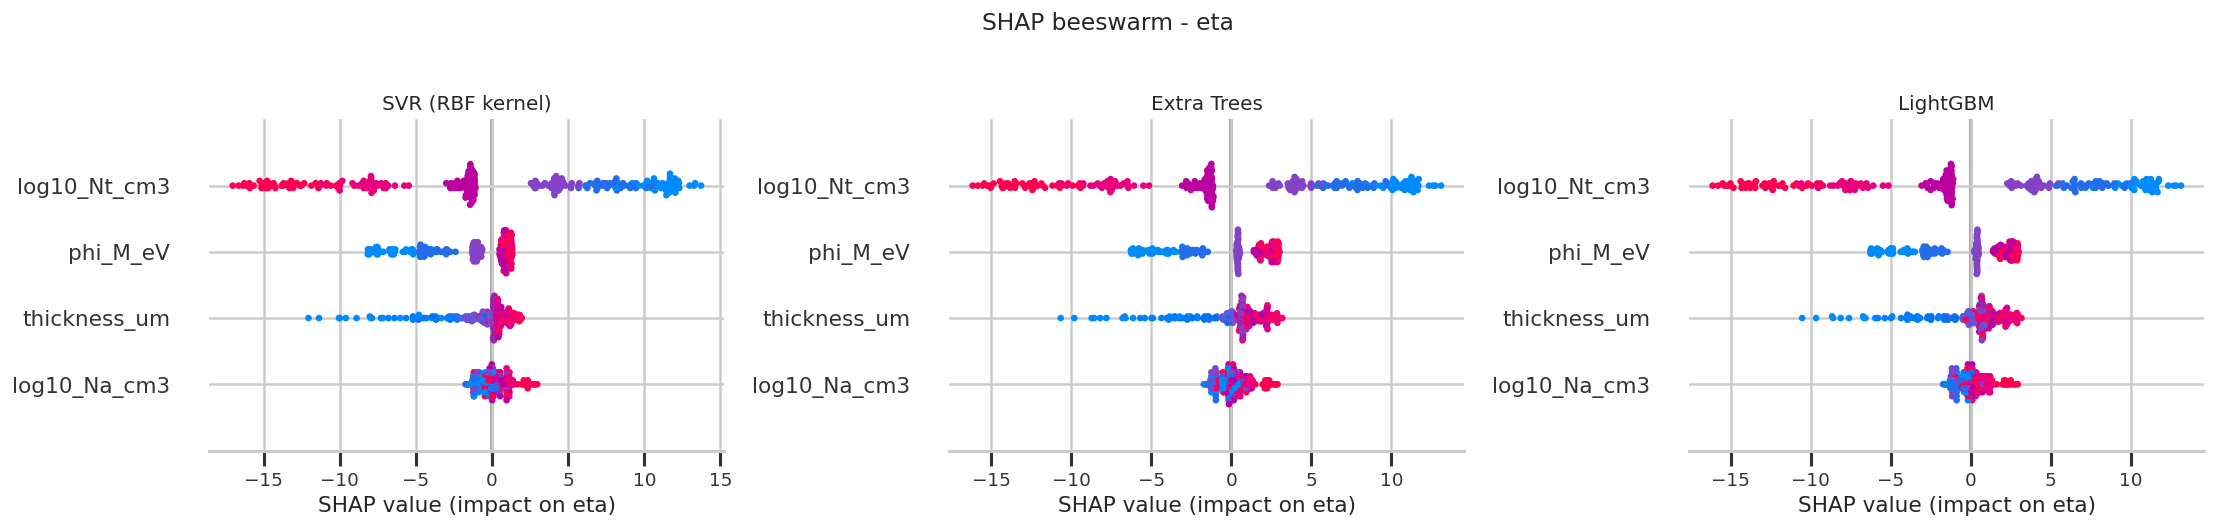

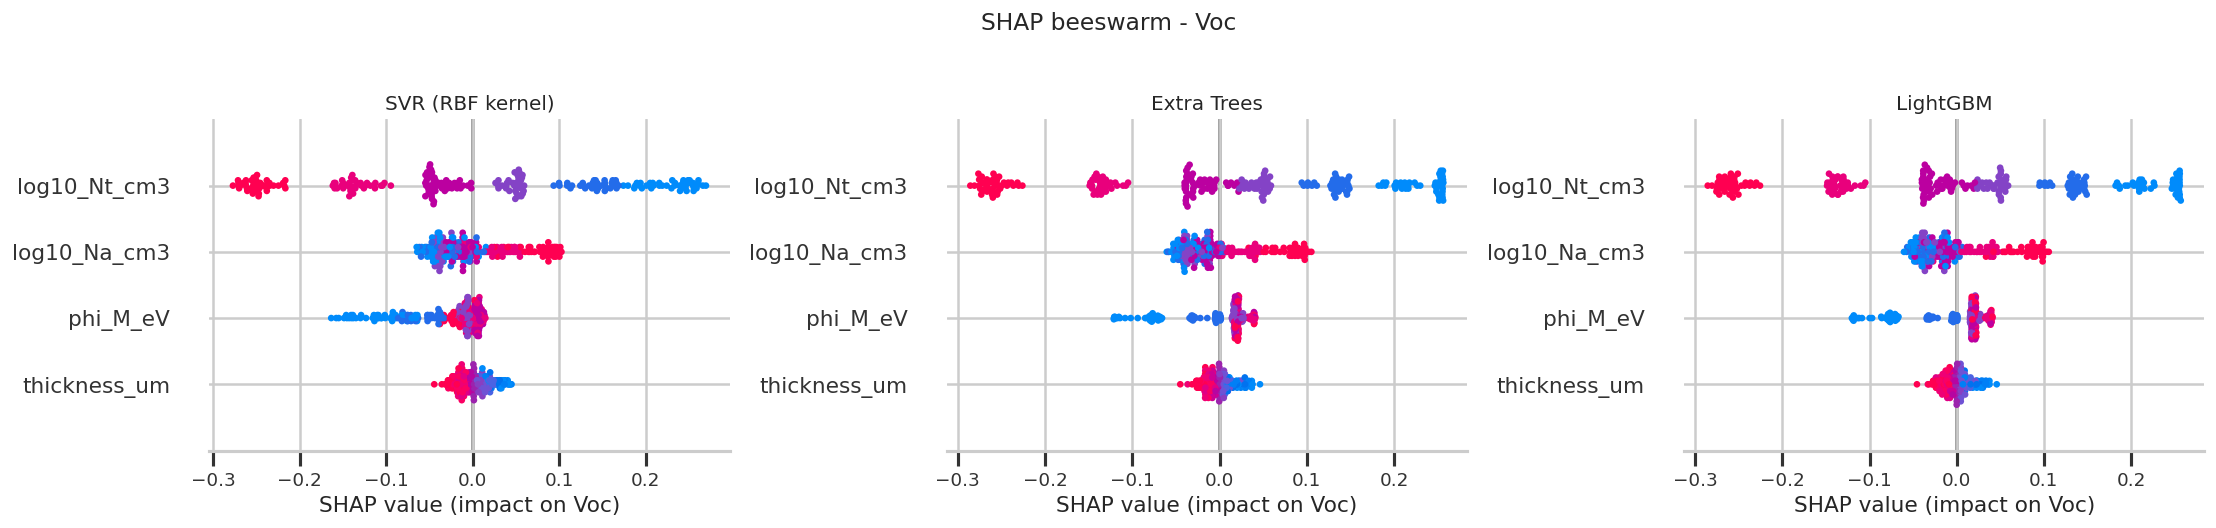

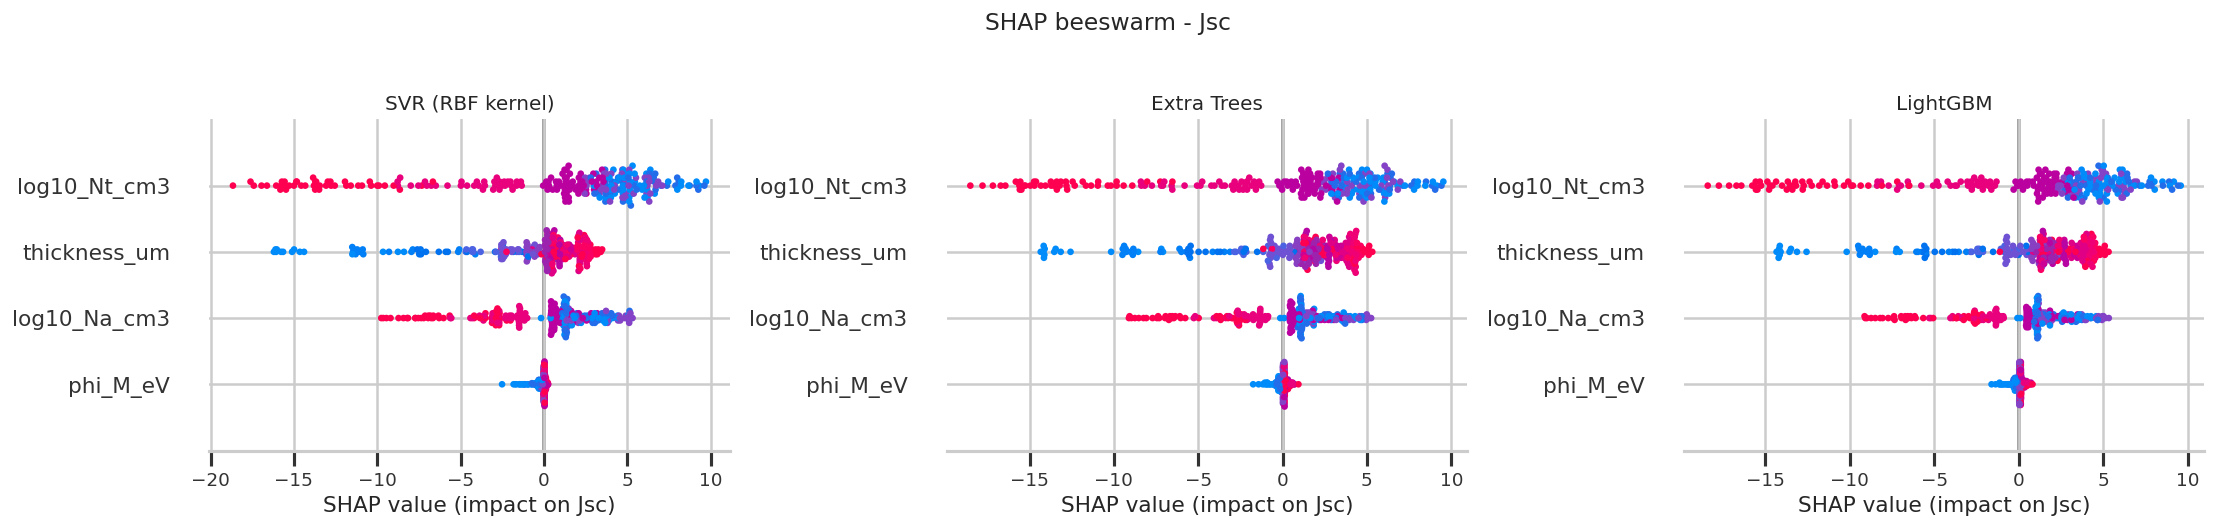

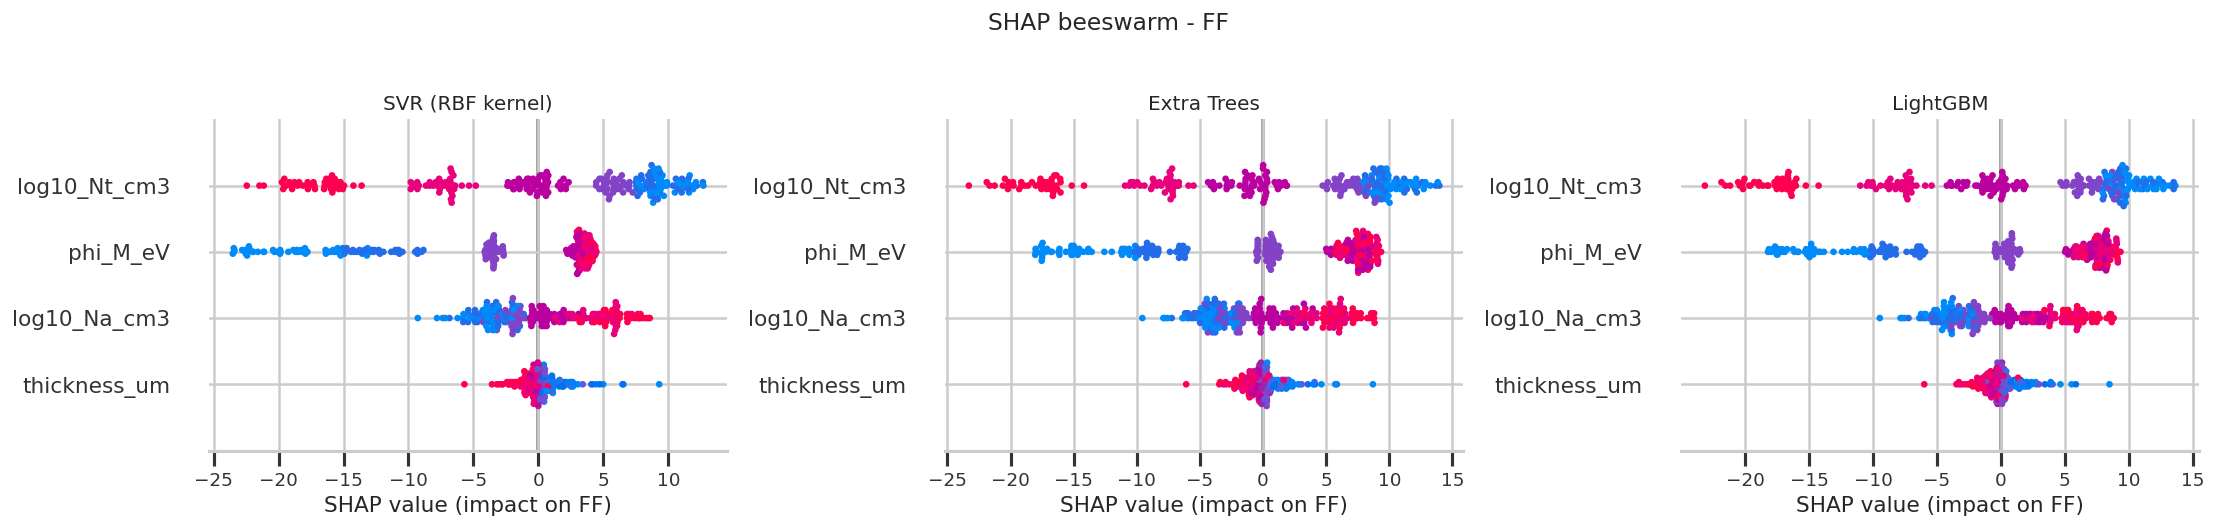

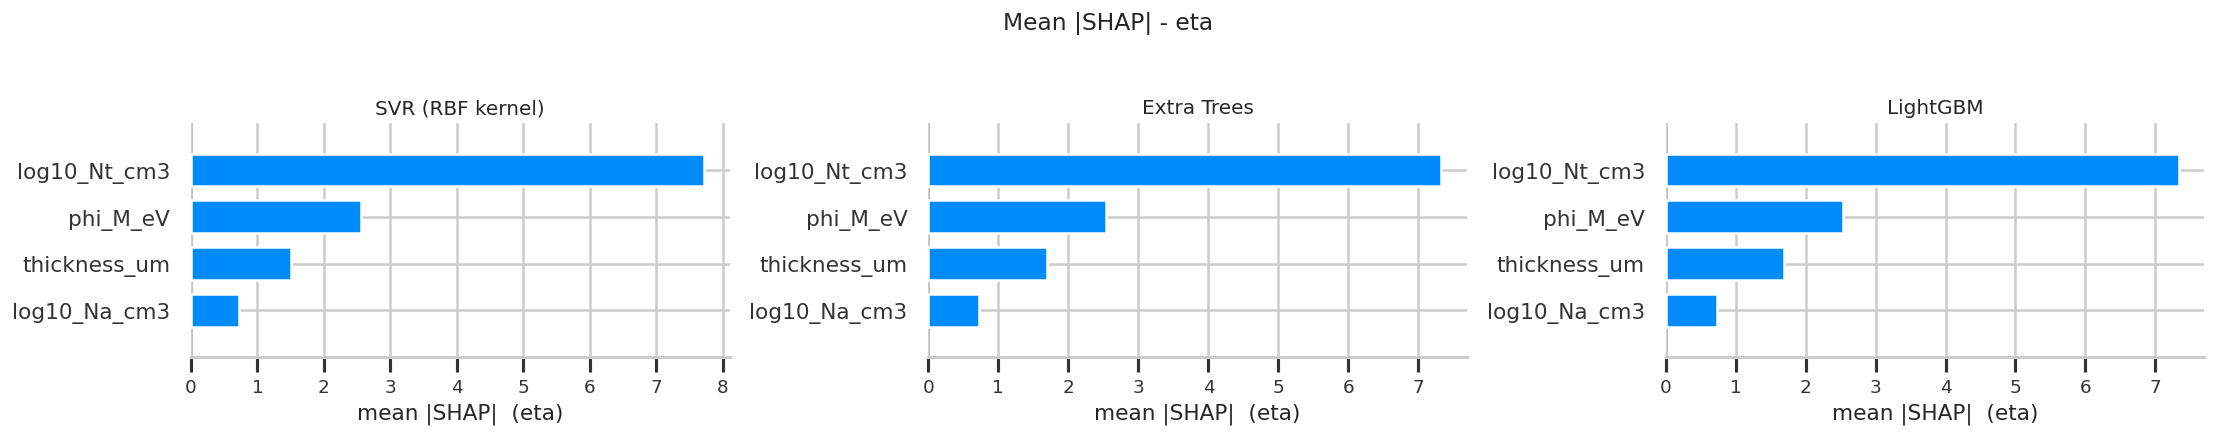

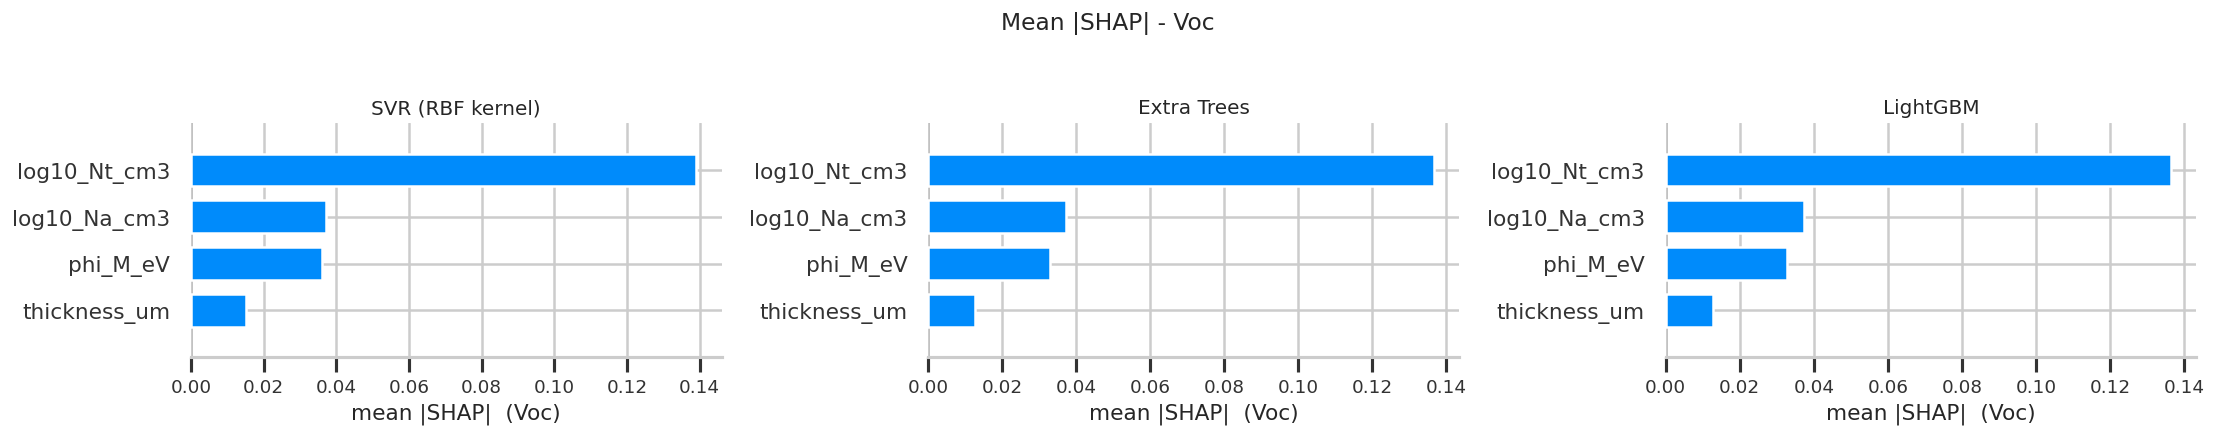

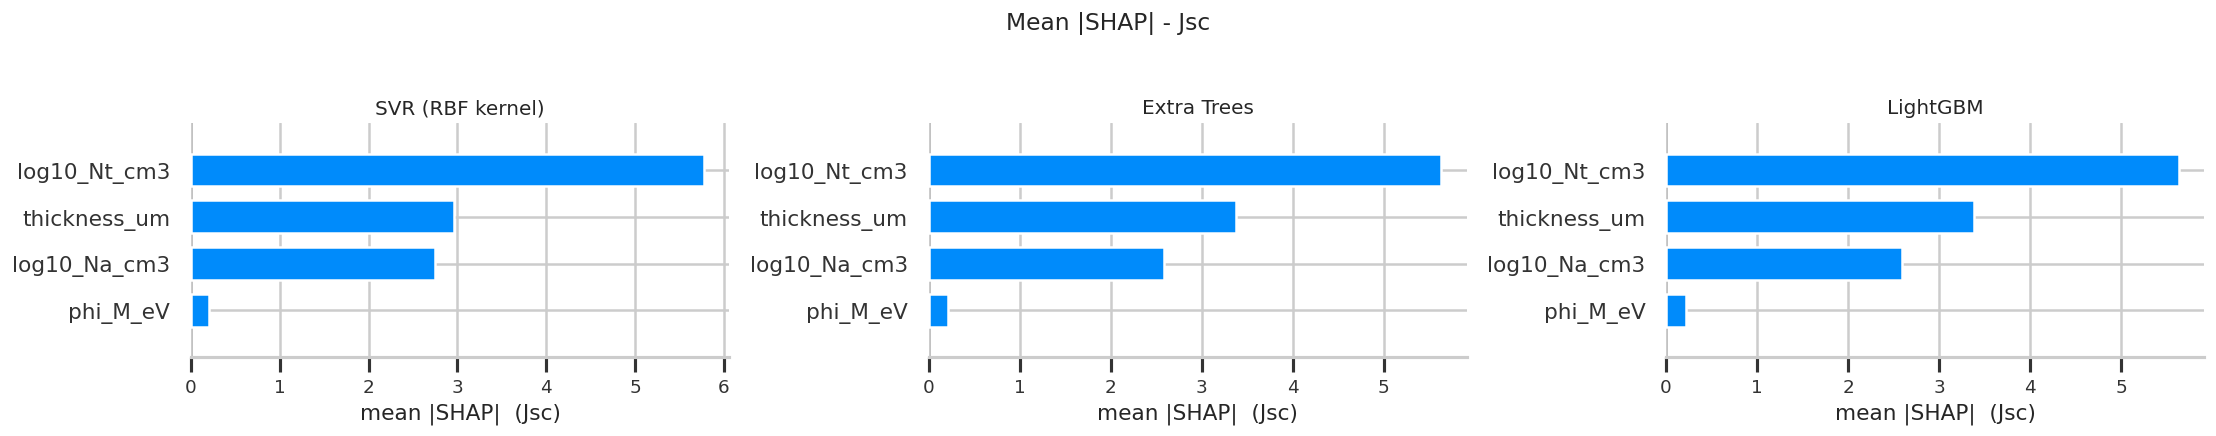

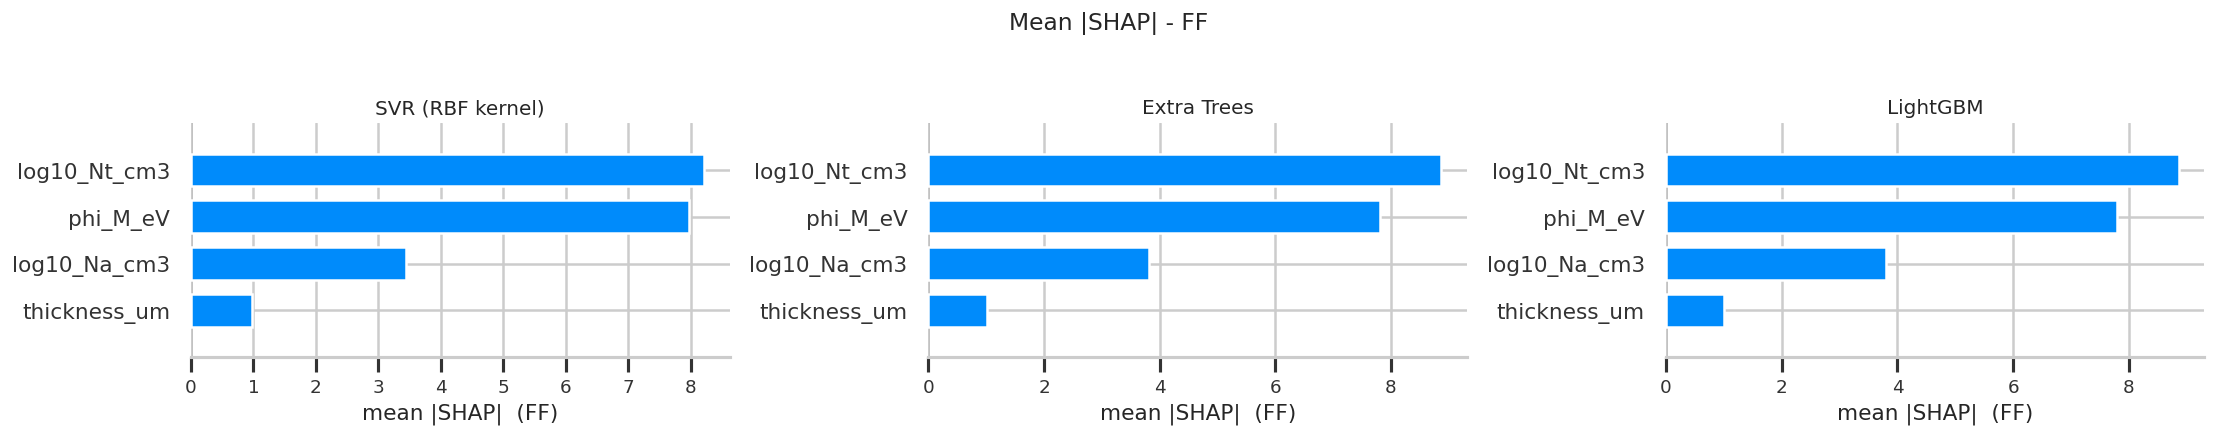

In [25]:
# ---------------------------------------------------------------
# 17 - SHAP beeswarm + bar grid (rows = models, cols = targets)
# ---------------------------------------------------------------
for tgt in TARGETS:
    fig, axes = plt.subplots(1, len(TOP3), figsize=(6.2 * len(TOP3), 4.2))
    for ax, name in zip(np.atleast_1d(axes), TOP3):
        sv, Xs = shap_store[(tgt, name)]
        plt.sca(ax)
        shap.summary_plot(sv, Xs, show=False, plot_size=None, color_bar=False)
        ax.set_title(f"{name}", fontsize=12)
        ax.set_xlabel(f"SHAP value (impact on {tgt})")
    plt.suptitle(f"SHAP beeswarm - {tgt}", y=1.04, fontsize=14)
    plt.tight_layout(); plt.savefig(f"{OUT}/fig_shap_beeswarm_{tgt}.png"); plt.show()

for tgt in TARGETS:
    fig, axes = plt.subplots(1, len(TOP3), figsize=(6.2 * len(TOP3), 3.4))
    for ax, name in zip(np.atleast_1d(axes), TOP3):
        sv, Xs = shap_store[(tgt, name)]
        plt.sca(ax)
        shap.summary_plot(sv, Xs, plot_type="bar", show=False, plot_size=None)
        ax.set_title(name, fontsize=12)
        ax.set_xlabel(f"mean |SHAP|  ({tgt})")
    plt.suptitle(f"Mean |SHAP| - {tgt}", y=1.06, fontsize=14)
    plt.tight_layout(); plt.savefig(f"{OUT}/fig_shap_bar_{tgt}.png"); plt.show()

### Do the three models agree?

If SVR, Extra Trees and LightGBM independently rank the features the same way,
the attribution reflects the device physics rather than one model's inductive
bias. That agreement is the claim worth making in a paper.

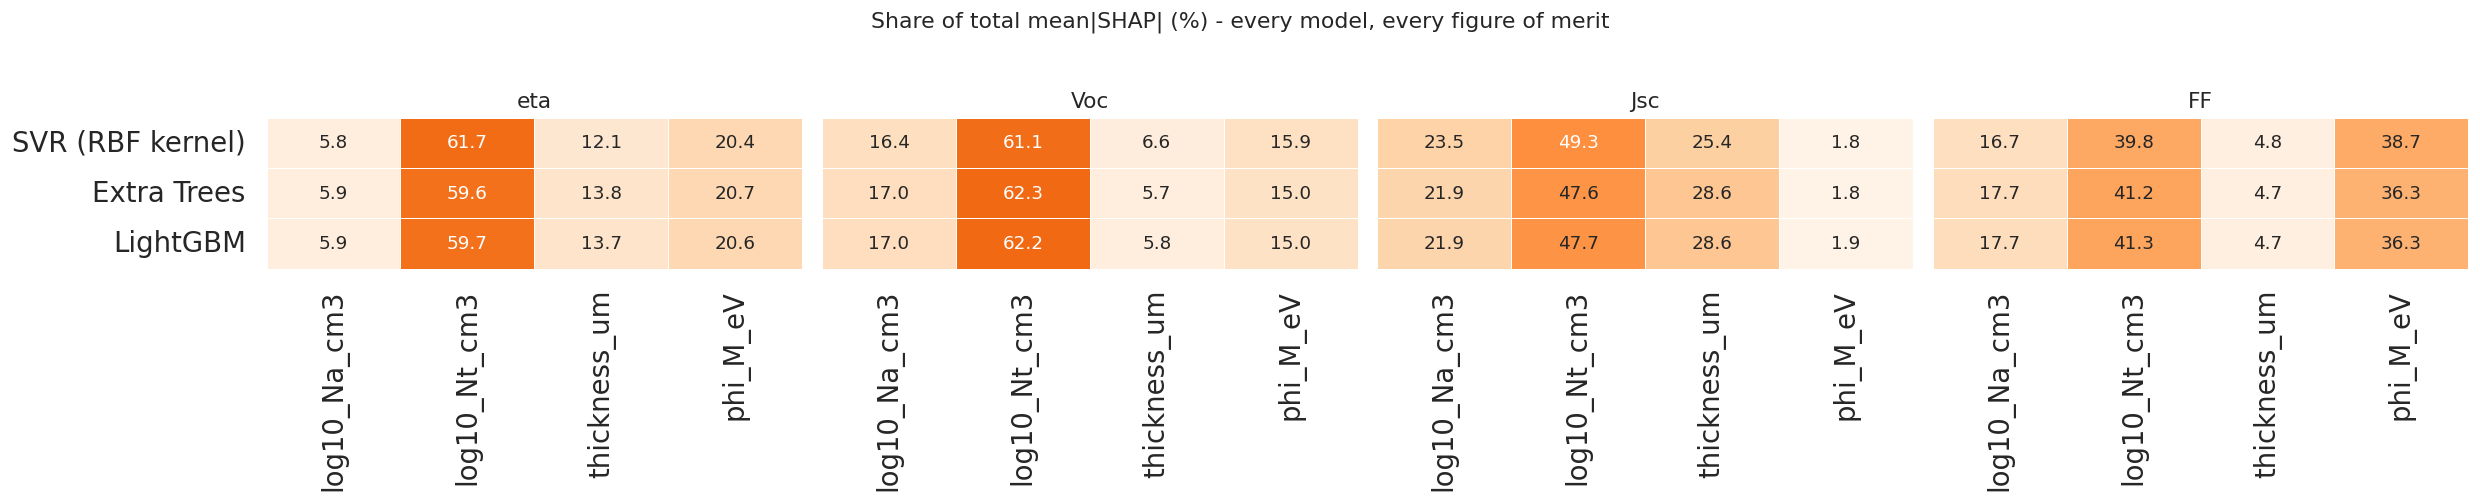

Feature ranked #1 by each model/target:
Target  Model           
eta     SVR (RBF kernel)    log10_Nt_cm3
        Extra Trees         log10_Nt_cm3
        LightGBM            log10_Nt_cm3
Voc     SVR (RBF kernel)    log10_Nt_cm3
        Extra Trees         log10_Nt_cm3
        LightGBM            log10_Nt_cm3
Jsc     SVR (RBF kernel)    log10_Nt_cm3
        Extra Trees         log10_Nt_cm3
        LightGBM            log10_Nt_cm3
FF      SVR (RBF kernel)    log10_Nt_cm3
        Extra Trees         log10_Nt_cm3
        LightGBM            log10_Nt_cm3

All models agree: log10_Nt_cm3 ranks #1 for every figure of merit.


,Target,Model,log10_Na_cm3,log10_Nt_cm3,thickness_um,phi_M_eV
0,eta,SVR (RBF kernel),5.78,61.74,12.06,20.42
1,eta,Extra Trees,5.94,59.61,13.80,20.66
2,eta,LightGBM,5.94,59.75,13.72,20.59
3,Voc,SVR (RBF kernel),16.39,61.11,6.64,15.87
4,Voc,Extra Trees,16.98,62.34,5.72,14.96
5,Voc,LightGBM,17.02,62.24,5.78,14.96
6,Jsc,SVR (RBF kernel),23.52,49.35,25.37,1.77
7,Jsc,Extra Trees,21.90,47.65,28.62,1.83
8,Jsc,LightGBM,21.90,47.66,28.59,1.85
9,FF,SVR (RBF kernel),16.70,39.84,4.75,38.71


In [26]:
# ---------------------------------------------------------------
# 18 - Consistency check: does every model agree on the ranking?
# ---------------------------------------------------------------
shap_imp = pd.DataFrame(imp_rows)
share = pd.DataFrame([r["_share"] for r in imp_rows], columns=FEATURES)
share.insert(0, "Model", shap_imp["Model"]); share.insert(0, "Target", shap_imp["Target"])
share.to_csv(f"{OUT}/shap_importance_share_all.csv", index=False)

fig, axes = plt.subplots(1, len(TARGETS), figsize=(5.2 * len(TARGETS), 4), sharey=True)
for ax, tgt in zip(np.atleast_1d(axes), TARGETS):
    sub = share[share.Target == tgt].set_index("Model")[FEATURES]
    sns.heatmap(sub, annot=True, fmt=".1f", cmap="Oranges", vmin=0, vmax=100,
                linewidths=.5, cbar=False, ax=ax)
    ax.set_title(tgt); ax.set_ylabel("")
plt.suptitle("Share of total mean|SHAP| (%) - every model, every figure of merit", y=1.04)
plt.tight_layout(); plt.savefig(f"{OUT}/fig_shap_share_grid.png"); plt.show()

print("Feature ranked #1 by each model/target:")
rank1 = share.set_index(["Target", "Model"])[FEATURES].idxmax(axis=1)
print(rank1.to_string())
if rank1.nunique() == 1:
    print(f"\nAll models agree: {rank1.iloc[0]} ranks #1 for every figure of merit.")
else:
    print("\nModels disagree on the #1 feature:", ", ".join(sorted(rank1.unique())))
display(share.round(2))

## 17 · Champion-cell prediction

Predicts all four figures of merit at the champion point: N_A = 10¹⁴ cm⁻³,
N_t = 10¹⁴ cm⁻³, thickness = 1400 nm, anode work function = 5.5 eV.

**Note the range check.** The batch sweep covers φ_M from 4.7 to 5.2 eV, so
5.5 eV is outside it. The cell reports the prediction at 5.5 eV as asked, and
also at 5.2 eV (the range edge), and compares both against the SCAPS value.
The 5.2 eV row exists in your dataset, so it gives a true ground-truth
comparison rather than a self-reported one.

In [27]:
# ---------------------------------------------------------------
# 19 - Champion-cell prediction (paper Table 5)
# ---------------------------------------------------------------
# Champion cell: Na = 1e14 cm-3, Nt = 1e14 cm-3, t = 1400 nm, phi_M = 5.5 eV
CHAMPION = {"log10_Na_cm3": 14.0, "log10_Nt_cm3": 14.0,
            "thickness_um": 1.4,  "phi_M_eV": 5.5}

# ---- range guard -------------------------------------------------
lo, hi = X.min(), X.max()
oob = {f: v for f, v in CHAMPION.items() if not (lo[f] <= v <= hi[f])}
for f, v in oob.items():
    print(f"!! {f} = {v} is OUTSIDE the swept range [{lo[f]}, {hi[f]}] -> EXTRAPOLATION")

# Nearest in-range point, used as the honest comparison
CLAMPED = {f: float(np.clip(v, lo[f], hi[f])) for f, v in CHAMPION.items()}
if oob:
    print("Clamped to the range edge:", CLAMPED)

pts = pd.DataFrame([CHAMPION, CLAMPED], index=["as asked", "clamped to range"])[FEATURES]

# ---- the SCAPS ground truth at the clamped point -----------------
key = np.isclose(df.log10_Na_cm3, CLAMPED["log10_Na_cm3"]) & \
      np.isclose(df.log10_Nt_cm3, CLAMPED["log10_Nt_cm3"]) & \
      np.isclose(df.thickness_um, CLAMPED["thickness_um"]) & \
      np.isclose(df.phi_M_eV,     CLAMPED["phi_M_eV"])
truth = df.loc[key, TARGETS].iloc[0] if key.any() else None
if truth is not None:
    print("\nSCAPS simulation at the clamped point:")
    print(truth.round(4).to_string())

# ---- predict -----------------------------------------------------
rows = []
for tgt in TARGETS:
    yt = y_all[tgt]
    for name in TOP3:
        mdl = model_zoo()[name].fit(X, yt)          # fit on ALL 3024 runs
        p = mdl.predict(pts)
        rec = {"Target": tgt, "Model": name,
               "Pred @ 5.5 eV": p[0], "Pred @ 5.2 eV (clamped)": p[1]}
        if truth is not None:
            rec["SCAPS"] = truth[tgt]
            rec["Acc @5.5 (%)"] = 100 * (1 - abs(p[0] - truth[tgt]) / abs(truth[tgt]))
            rec["Acc @5.2 (%)"] = 100 * (1 - abs(p[1] - truth[tgt]) / abs(truth[tgt]))
        rows.append(rec)

champ = pd.DataFrame(rows)
champ.to_csv(f"{OUT}/champion_cell_prediction.csv", index=False)
display(champ.round(4))

# ---- physical sanity check --------------------------------------
print("\nSanity: is any prediction outside the range SCAPS ever produced?")
for tgt in TARGETS:
    tl, th = df[tgt].min(), df[tgt].max()
    bad = champ[(champ.Target == tgt) &
                ((champ["Pred @ 5.5 eV"] < tl) | (champ["Pred @ 5.5 eV"] > th))]
    for _, b in bad.iterrows():
        print(f"  {b.Model} predicts {tgt} = {b['Pred @ 5.5 eV']:.3f}, "
              f"outside the simulated range [{tl:.3f}, {th:.3f}] - UNPHYSICAL")

!! phi_M_eV = 5.5 is OUTSIDE the swept range [4.7, 5.2] -> EXTRAPOLATION
Clamped to the range edge: {'log10_Na_cm3': 14.0, 'log10_Nt_cm3': 14.0, 'thickness_um': 1.4, 'phi_M_eV': 5.2}

SCAPS simulation at the clamped point:
eta    29.2926
Voc     0.8586
Jsc    43.2593
FF     78.8700


,Target,Model,Pred @ 5.5 eV,Pred @ 5.2 eV (clamped),SCAPS,Acc @5.5 (%),Acc @5.2 (%)
0,eta,SVR (RBF kernel),34.2062,29.3022,29.2926,83.2257,99.9672
1,eta,Extra Trees,29.2926,29.2926,29.2926,100.0000,100.0000
2,eta,LightGBM,29.3041,29.3041,29.2926,99.9606,99.9606
3,Voc,SVR (RBF kernel),0.7669,0.8638,0.8586,89.3293,99.3844
4,Voc,Extra Trees,0.8586,0.8586,0.8586,100.0000,100.0000
5,Voc,LightGBM,0.8587,0.8587,0.8586,99.9852,99.9852
6,Jsc,SVR (RBF kernel),34.3545,43.2089,43.2593,79.4154,99.8836
7,Jsc,Extra Trees,43.2593,43.2593,43.2593,100.0000,100.0000
8,Jsc,LightGBM,43.2716,43.2716,43.2593,99.9715,99.9715
9,FF,SVR (RBF kernel),97.3820,79.4310,78.8700,76.5284,99.2887



Sanity: is any prediction outside the range SCAPS ever produced?
  SVR (RBF kernel) predicts FF = 97.382, outside the simulated range [19.593, 88.320] - UNPHYSICAL


### Why the 5.5 eV request is a special case

The work-function response saturates once the contact turns ohmic above ~5.1 eV:
between 5.1 and 5.2 eV, η moves by 0.009 %. So the physically correct answer at
5.5 eV is the 5.2 eV answer. Tree ensembles reproduce that by accident — they
clamp at the edge of the training data. SVR's RBF kernel does not clamp; it
drifts once it leaves the data. This plot shows which models stay physical.

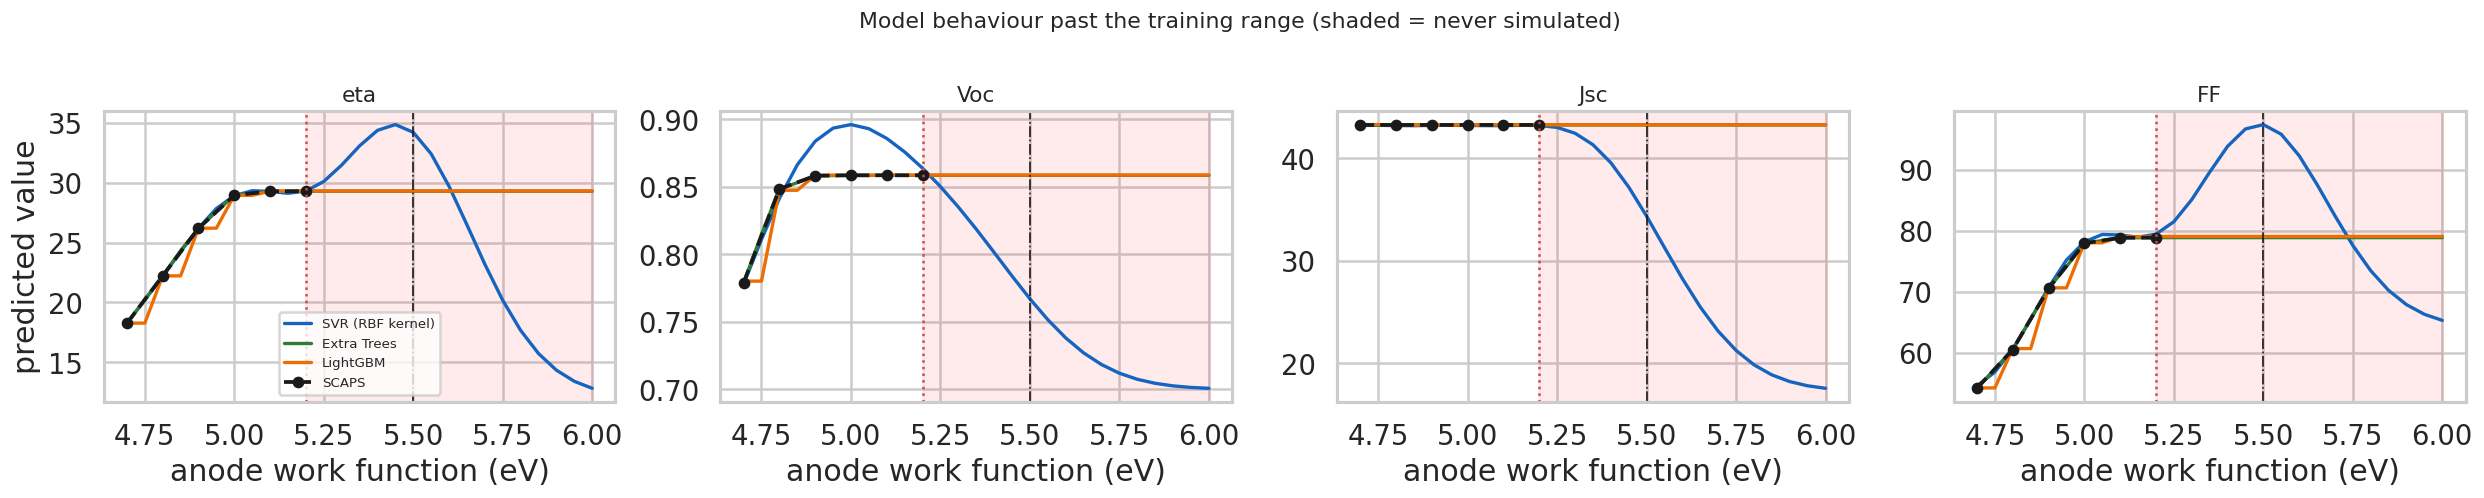

In [28]:
# ---------------------------------------------------------------
# 20 - Why 5.5 eV is safe here: the work-function response saturates
# ---------------------------------------------------------------
base = {k: v for k, v in CHAMPION.items() if k != "phi_M_eV"}
grid = pd.DataFrame([{**base, "phi_M_eV": p} for p in np.arange(4.7, 6.01, 0.05)])[FEATURES]
sim  = df[(np.isclose(df.log10_Na_cm3, base["log10_Na_cm3"])) &
          (np.isclose(df.log10_Nt_cm3, base["log10_Nt_cm3"])) &
          (np.isclose(df.thickness_um, base["thickness_um"]))].sort_values("phi_M_eV")

fig, axes = plt.subplots(1, len(TARGETS), figsize=(5.2 * len(TARGETS), 4))
for ax, tgt in zip(np.atleast_1d(axes), TARGETS):
    for name, c in zip(TOP3, ["#1565c0", "#2e7d32", "#ef6c00"]):
        mdl = model_zoo()[name].fit(X, y_all[tgt])
        ax.plot(grid.phi_M_eV, mdl.predict(grid), "-", color=c, lw=2, label=name)
    ax.plot(sim.phi_M_eV, sim[tgt], "ko--", ms=6, label="SCAPS")
    ax.axvspan(hi["phi_M_eV"], 6.0, color="red", alpha=.08)
    ax.axvline(hi["phi_M_eV"], color="r", ls=":", lw=1.5)
    ax.axvline(CHAMPION["phi_M_eV"], color="k", ls="-.", lw=1)
    ax.set_xlabel("anode work function (eV)"); ax.set_title(tgt)
np.atleast_1d(axes)[0].set_ylabel("predicted value")
np.atleast_1d(axes)[0].legend(fontsize=8)
plt.suptitle("Model behaviour past the training range (shaded = never simulated)", y=1.03)
plt.tight_layout(); plt.savefig(f"{OUT}/fig_workfunction_extrapolation.png"); plt.show()